<a href="https://colab.research.google.com/github/Raajarapu/COLAB_practice/blob/main/Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading the dataset
data = pd.read_csv("Turbine_Data.csv")

In [ ]:
data

,Unnamed: 0,ActivePower,AmbientTemperatue,BearingShaftTemperature,Blade1PitchAngle,Blade2PitchAngle,Blade3PitchAngle,ControlBoxTemperature,GearboxBearingTemperature,GearboxOilTemperature,...,GeneratorWinding2Temperature,HubTemperature,MainBoxTemperature,NacellePosition,ReactivePower,RotorRPM,TurbineStatus,WTG,WindDirection,WindSpeed
0,2017-12-31 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
1,2017-12-31 00:10:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
2,2017-12-31 00:20:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
3,2017-12-31 00:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
4,2017-12-31 00:40:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76633,2019-06-16 04:10:00+00:00,1291.142812,30.336102,50.375869,-0.678487,0.134734,0.134734,0.0,75.939452,63.912812,...,92.885697,40.007488,42.693743,NaN,260.500563,14.205384,2.0,G01,NaN,7.973000
76634,2019-06-16 04:20:00+00:00,1192.049160,30.372134,40.304602,-0.616208,-0.453561,-0.453561,0.0,60.827097,64.066500,...,92.779063,32.005429,34.473909,239.0,253.366949,14.248935,2.0,G01,239.0,7.713330
76635,2019-06-16 04:30:00+00:00,1099.543840,30.565006,50.196596,-0.606599,-0.219071,-0.219071,0.0,75.179745,63.632744,...,91.419870,40.011800,43.200265,351.5,225.505244,13.672926,2.0,G01,351.5,7.404665
76636,2019-06-16 04:40:00+00:00,1373.921665,30.960474,50.272598,-0.328494,0.046723,0.046723,0.0,76.051243,64.060992,...,92.365488,40.373109,43.318750,72.6,278.440745,14.706997,2.0,G01,72.6,8.242575


In [ ]:
data.info() # Information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76638 entries, 0 to 76637
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    76638 non-null  object 
 1   ActivePower                   57208 non-null  float64
 2   AmbientTemperatue             57099 non-null  float64
 3   BearingShaftTemperature       25764 non-null  float64
 4   Blade1PitchAngle              4810 non-null   float64
 5   Blade2PitchAngle              4826 non-null   float64
 6   Blade3PitchAngle              4826 non-null   float64
 7   ControlBoxTemperature         25615 non-null  float64
 8   GearboxBearingTemperature     25765 non-null  float64
 9   GearboxOilTemperature         25721 non-null  float64
 10  GeneratorRPM                  25636 non-null  float64
 11  GeneratorWinding1Temperature  25722 non-null  float64
 12  GeneratorWinding2Temperature  25721 non-null  float64
 13  H

In [ ]:
data.head() # Top 5 rows

,Unnamed: 0,ActivePower,AmbientTemperatue,BearingShaftTemperature,Blade1PitchAngle,Blade2PitchAngle,Blade3PitchAngle,ControlBoxTemperature,GearboxBearingTemperature,GearboxOilTemperature,...,GeneratorWinding2Temperature,HubTemperature,MainBoxTemperature,NacellePosition,ReactivePower,RotorRPM,TurbineStatus,WTG,WindDirection,WindSpeed
0,2017-12-31 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
1,2017-12-31 00:10:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
2,2017-12-31 00:20:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
3,2017-12-31 00:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
4,2017-12-31 00:40:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN


In [ ]:
data.tail() # last Five rows

,Unnamed: 0,ActivePower,AmbientTemperatue,BearingShaftTemperature,Blade1PitchAngle,Blade2PitchAngle,Blade3PitchAngle,ControlBoxTemperature,GearboxBearingTemperature,GearboxOilTemperature,...,GeneratorWinding2Temperature,HubTemperature,MainBoxTemperature,NacellePosition,ReactivePower,RotorRPM,TurbineStatus,WTG,WindDirection,WindSpeed
76633,2019-06-16 04:10:00+00:00,1291.142812,30.336102,50.375869,-0.678487,0.134734,0.134734,0.0,75.939452,63.912812,...,92.885697,40.007488,42.693743,NaN,260.500563,14.205384,2.0,G01,NaN,7.973000
76634,2019-06-16 04:20:00+00:00,1192.049160,30.372134,40.304602,-0.616208,-0.453561,-0.453561,0.0,60.827097,64.066500,...,92.779063,32.005429,34.473909,239.0,253.366949,14.248935,2.0,G01,239.0,7.713330
76635,2019-06-16 04:30:00+00:00,1099.543840,30.565006,50.196596,-0.606599,-0.219071,-0.219071,0.0,75.179745,63.632744,...,91.419870,40.011800,43.200265,351.5,225.505244,13.672926,2.0,G01,351.5,7.404665
76636,2019-06-16 04:40:00+00:00,1373.921665,30.960474,50.272598,-0.328494,0.046723,0.046723,0.0,76.051243,64.060992,...,92.365488,40.373109,43.318750,72.6,278.440745,14.706997,2.0,G01,72.6,8.242575
76637,2019-06-16 04:50:00+00:00,952.409298,31.218051,50.224508,-1.004721,-0.532265,-0.532265,0.0,75.336961,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data.shape # NO.of rows and columns

(76638, 22)

In [ ]:
data.describe().T # Describing the dataset

,count,mean,std,min,25%,50%,75%,max
ActivePower,57208.0,574.049663,592.311270,-38.312299,60.669444,359.129610,952.449486,1767.288800
AmbientTemperatue,57099.0,29.519996,4.696138,0.000000,26.068036,29.208503,32.613063,42.405597
BearingShaftTemperature,25764.0,43.203043,5.581900,0.000000,40.143929,43.567442,46.761009,55.088655
Blade1PitchAngle,4810.0,10.700530,20.245113,-1.320658,-0.805631,0.773039,10.223814,90.143610
Blade2PitchAngle,4826.0,11.038678,20.109534,-0.851970,-0.342354,1.226606,10.460084,90.017830
Blade3PitchAngle,4826.0,11.038678,20.109534,-0.851970,-0.342354,1.226606,10.460084,90.017830
ControlBoxTemperature,25615.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GearboxBearingTemperature,25765.0,63.594549,9.727308,0.000000,57.303253,64.037145,70.220271,81.420081
GearboxOilTemperature,25721.0,57.587293,4.705774,0.000000,54.478086,57.245675,60.696467,69.930297
GeneratorRPM,25636.0,1045.484678,520.293448,0.000000,957.031656,1080.240045,1416.789568,1793.657150


In [ ]:
data.columns # Features in dataset

Index(['Unnamed: 0', 'ActivePower', 'AmbientTemperatue',
       'BearingShaftTemperature', 'Blade1PitchAngle', 'Blade2PitchAngle',
       'Blade3PitchAngle', 'ControlBoxTemperature',
       'GearboxBearingTemperature', 'GearboxOilTemperature', 'GeneratorRPM',
       'GeneratorWinding1Temperature', 'GeneratorWinding2Temperature',
       'HubTemperature', 'MainBoxTemperature', 'NacellePosition',
       'ReactivePower', 'RotorRPM', 'TurbineStatus', 'WTG', 'WindDirection',
       'WindSpeed'],
      dtype='object')

In [ ]:
data.isna().sum()

,0
Unnamed: 0,0
ActivePower,19430
AmbientTemperatue,19539
BearingShaftTemperature,50874
Blade1PitchAngle,71828
Blade2PitchAngle,71812
Blade3PitchAngle,71812
ControlBoxTemperature,51023
GearboxBearingTemperature,50873
GearboxOilTemperature,50917


In [ ]:
# Filling with default value
data['Blade1PitchAngle'] = data['Blade1PitchAngle'].fillna(0)

# Filling with mean
data['AmbientTemperatue'] = data['AmbientTemperatue'].fillna(data['AmbientTemperatue'].mean())

# Filling with median
data['GeneratorRPM'] = data['GeneratorRPM'].fillna(data['GeneratorRPM'].median())

# Filling with mode
data['TurbineStatus'] = data['TurbineStatus'].fillna(data['TurbineStatus'].mode()[0])

# Forward fill
data['WindSpeed'] = data['WindSpeed'].fillna(method='ffill')

# Backward fill
data['GearboxBearingTemperature'] = data['GearboxBearingTemperature'].fillna(method='bfill')

# Interpolation
data['RotorRPM'] = data['RotorRPM'].interpolate(method='linear')

<ipython-input-19-d27b80825e34>:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['WindSpeed'] = data['WindSpeed'].fillna(method='ffill')
<ipython-input-19-d27b80825e34>:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['GearboxBearingTemperature'] = data['GearboxBearingTemperature'].fillna(method='bfill')


In [ ]:
data.isna().sum()

,0
Unnamed: 0,0
ActivePower,19430
AmbientTemperatue,0
BearingShaftTemperature,50874
Blade1PitchAngle,0
Blade2PitchAngle,71812
Blade3PitchAngle,71812
ControlBoxTemperature,51023
GearboxBearingTemperature,0
GearboxOilTemperature,50917


In [ ]:
# Filling with Mean values
data['BearingShaftTemperature'] = data['BearingShaftTemperature'].fillna(data['BearingShaftTemperature'].mean())

In [ ]:
# Filling with Median values
data['Blade2PitchAngle'] = data['Blade2PitchAngle'].fillna(data['Blade2PitchAngle'].median())

In [ ]:
# Filling with Mode values
data['Blade3PitchAngle'] = data['Blade3PitchAngle'].fillna(data['Blade3PitchAngle'].mode()[0])

In [ ]:
# Filling with Forward values
data['ControlBoxTemperature'] = data['ControlBoxTemperature'].fillna(method='ffill')

<ipython-input-24-b78dc7d1644c>:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['ControlBoxTemperature'] = data['ControlBoxTemperature'].fillna(method='ffill')


In [ ]:
# Filling with Backward values
data['GearboxOilTemperature'] = data['GearboxOilTemperature'].fillna(method='bfill')

<ipython-input-25-8bc2b9361650>:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['GearboxOilTemperature'] = data['GearboxOilTemperature'].fillna(method='bfill')


In [ ]:
# Filling with Linear interpolate values
data['GeneratorWinding1Temperature'] = data['GeneratorWinding1Temperature'].interpolate(method='linear')

In [ ]:
# Filling with nearest interpolate values
data['GeneratorWinding2Temperature'] = data['GeneratorWinding2Temperature'].interpolate(method='nearest')

In [ ]:
# Filling with Mean
data['HubTemperature'] = data['HubTemperature'].fillna(data['HubTemperature'].mean())

In [ ]:
# Filling with Median
data['MainBoxTemperature'] = data['MainBoxTemperature'].fillna(data['MainBoxTemperature'].median())

In [ ]:
# Filling with Mode Values
data['NacellePosition'] = data['NacellePosition'].fillna(data['NacellePosition'].mode()[0])

In [ ]:
# Forward Filling
data['ReactivePower'] = data['ReactivePower'].ffill()

In [ ]:
# Backward Filling
data['RotorRPM'] = data['RotorRPM'].bfill()

In [ ]:
# Filling with Linear interpolate values
data['WindDirection'] = data['WindDirection'].interpolate(method='linear')

In [ ]:
# Filling with nearest interpolate values
data['WindSpeed'] = data['WindSpeed'].interpolate(method='nearest')

In [ ]:
data.isna().sum()

,0
Unnamed: 0,0
ActivePower,19430
AmbientTemperatue,0
BearingShaftTemperature,0
Blade1PitchAngle,0
Blade2PitchAngle,0
Blade3PitchAngle,0
ControlBoxTemperature,33065
GearboxBearingTemperature,0
GearboxOilTemperature,1


In [ ]:
data['ControlBoxTemperature'] = data['ControlBoxTemperature'].fillna(data['ControlBoxTemperature'].mean())

In [ ]:
data['GeneratorWinding1Temperature'] = data['GeneratorWinding1Temperature'].fillna(data['GeneratorWinding1Temperature'].median())

In [ ]:
data['GeneratorWinding2Temperature'] = data['GeneratorWinding2Temperature'].fillna(data['GeneratorWinding2Temperature'].median())

In [ ]:
data['ReactivePower'] = data['ReactivePower'].fillna(data['ReactivePower'].mode()[0])

In [ ]:
data['WindDirection'] = data['WindDirection'].fillna(data['WindDirection'].mean())

In [ ]:
data['ActivePower'] = data['ActivePower'].fillna(data['ActivePower'].mean())

In [ ]:
data['WindSpeed'] = data['WindSpeed'].fillna(data['WindSpeed'].median())

In [ ]:
data.isna().sum()

,0
Unnamed: 0,0
ActivePower,0
AmbientTemperatue,0
BearingShaftTemperature,0
Blade1PitchAngle,0
Blade2PitchAngle,0
Blade3PitchAngle,0
ControlBoxTemperature,0
GearboxBearingTemperature,0
GearboxOilTemperature,1


In [ ]:
data.describe().T # Describing the dataset after filling the null values

,count,mean,std,min,25%,50%,75%,max
ActivePower,76638.0,574.049663,511.747035,-38.312299,149.807515,574.049663,679.329902,1767.288800
AmbientTemperatue,76638.0,29.519996,4.053517,0.000000,27.187530,29.519996,31.362804,42.405597
BearingShaftTemperature,76638.0,43.203043,3.236392,0.000000,43.203043,43.203043,43.203043,55.088655
Blade1PitchAngle,76638.0,0.671593,5.696894,-1.320658,0.000000,0.000000,0.000000,90.143610
Blade2PitchAngle,76638.0,1.844486,5.580434,-0.851970,1.226606,1.226606,1.226606,90.017830
Blade3PitchAngle,76638.0,80.342554,18.661284,-0.851970,85.000000,85.000000,85.000000,90.017830
ControlBoxTemperature,76638.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GearboxBearingTemperature,76638.0,70.036098,12.638756,0.000000,67.235971,72.779137,77.119133,81.420081
GearboxOilTemperature,76637.0,61.007198,4.492557,0.000000,59.053995,61.890381,64.204399,69.930297
GeneratorRPM,76638.0,1068.614107,301.362818,0.000000,1080.240045,1080.240045,1080.240045,1793.657150


# Exploratory Data Analysis (EDA)

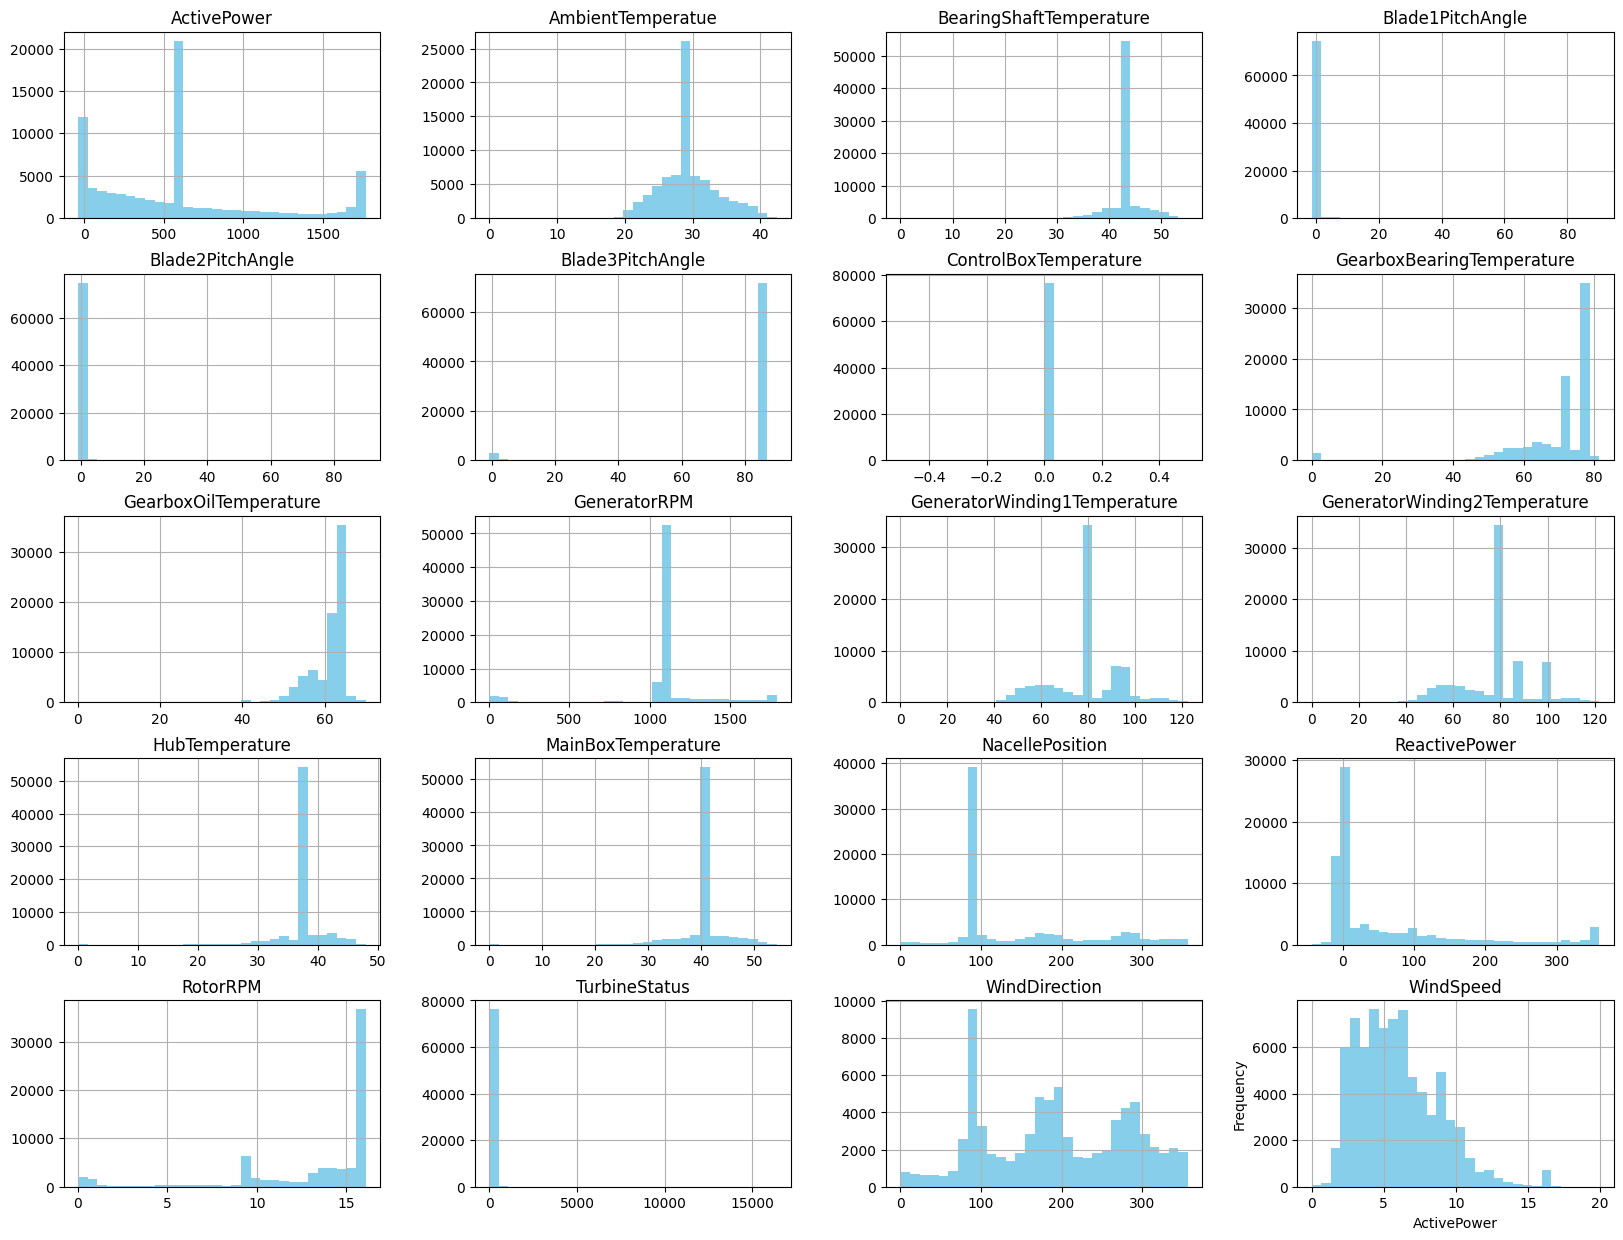

In [ ]:
data.hist(figsize=(20,15), bins=30, color='skyblue')
plt.xlabel("ActivePower")
plt.ylabel("Frequency")
plt.show()

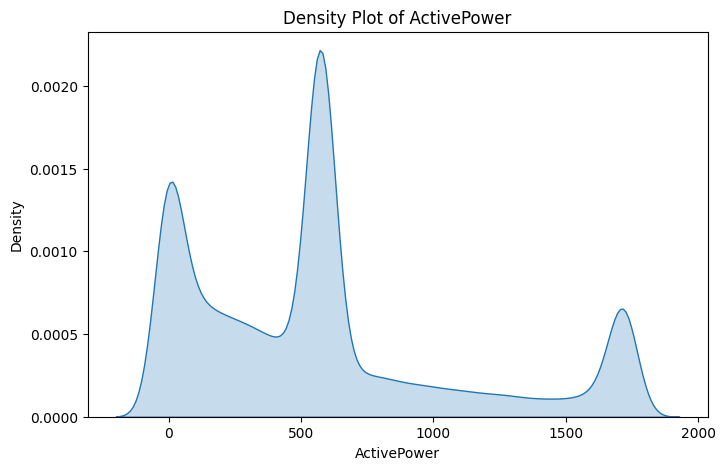

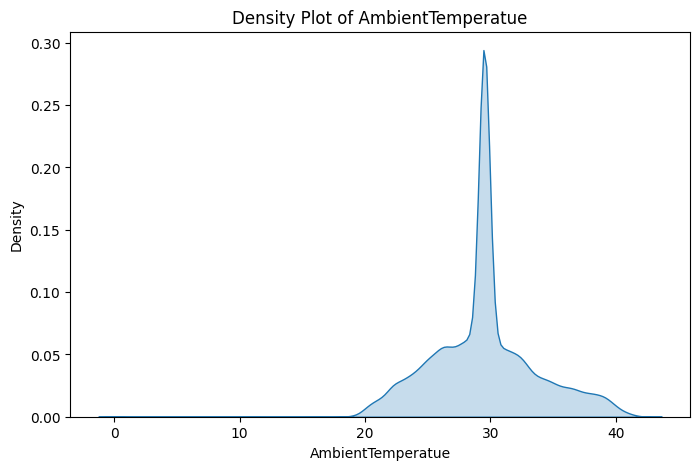

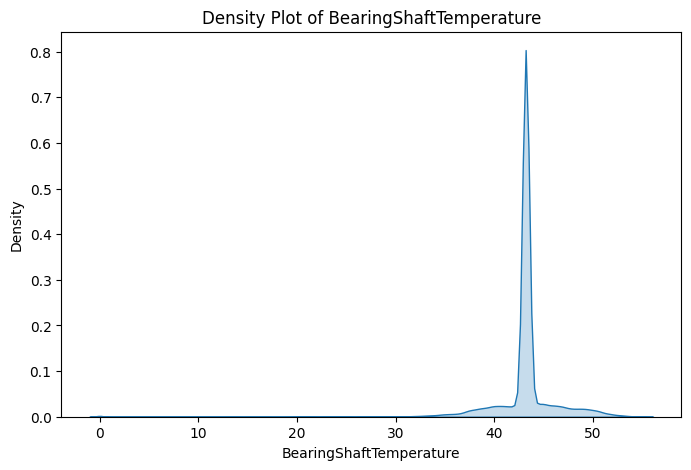

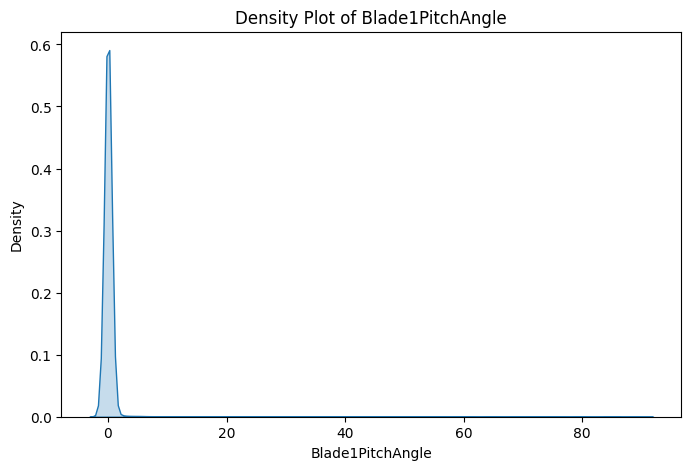

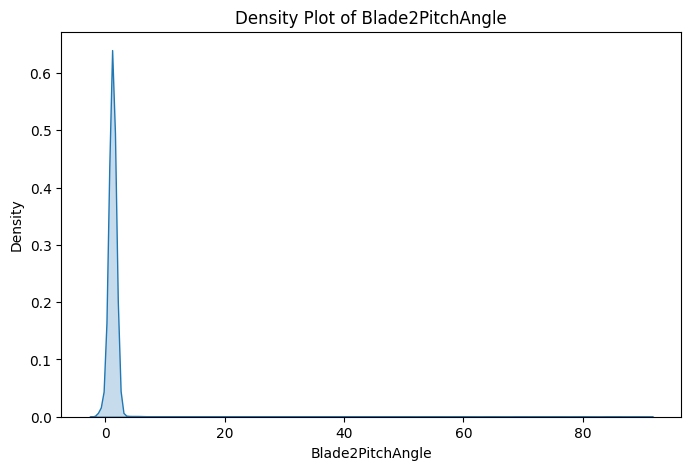

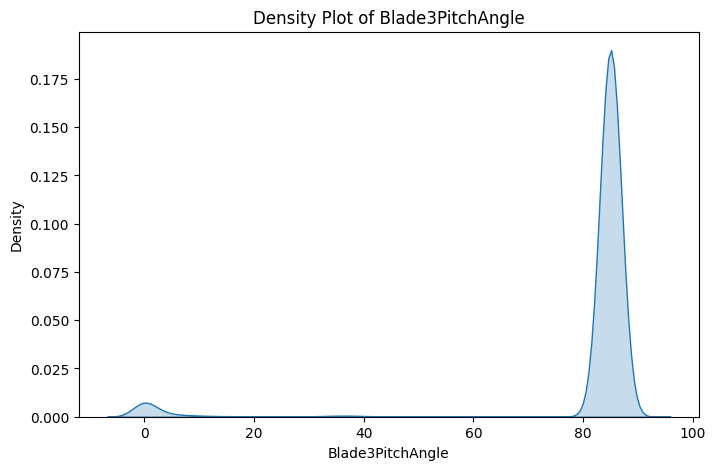

<ipython-input-46-154d6d284df9>:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data[column], fill=True)


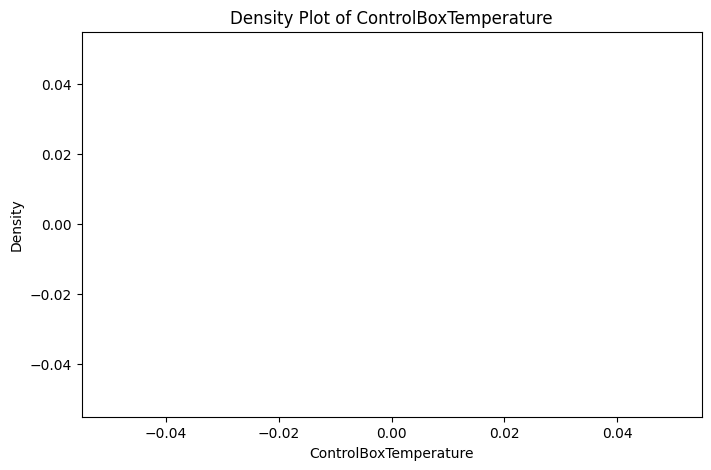

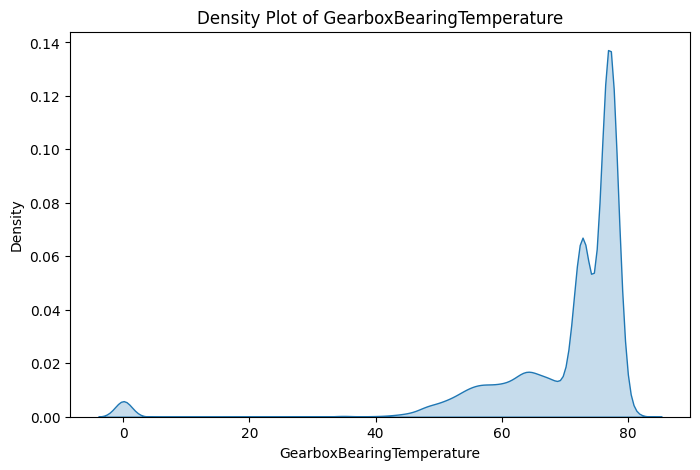

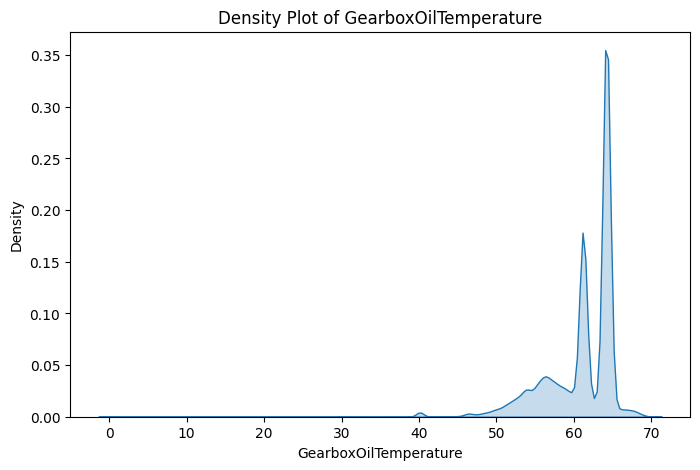

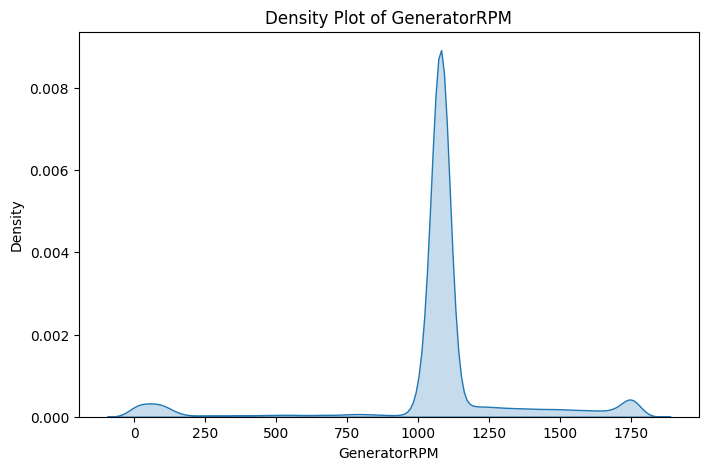

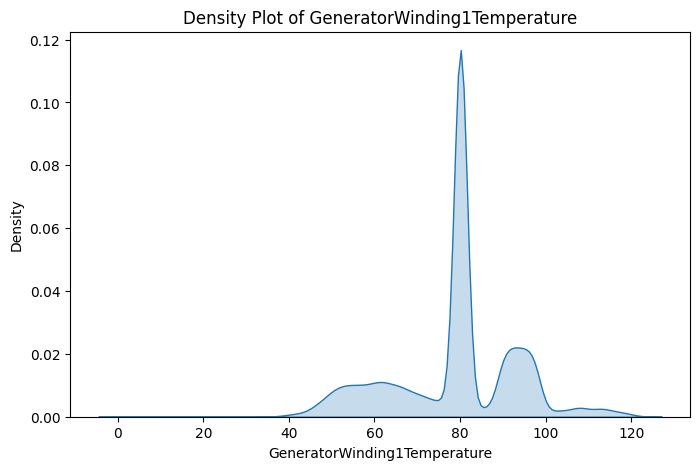

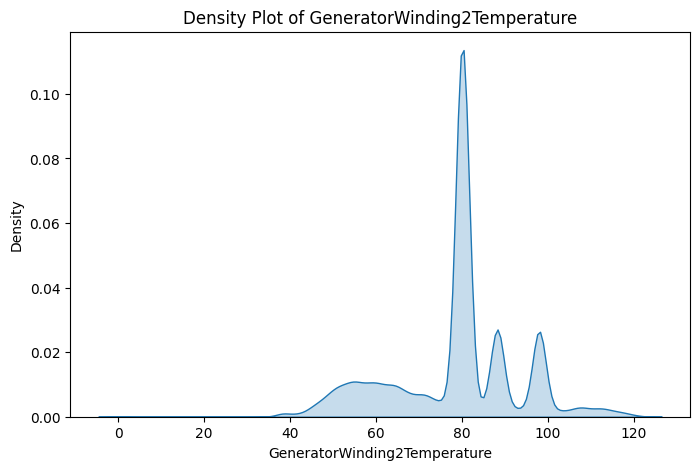

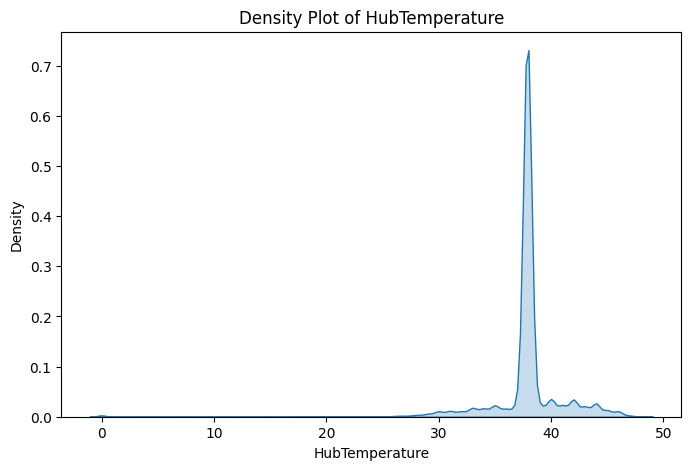

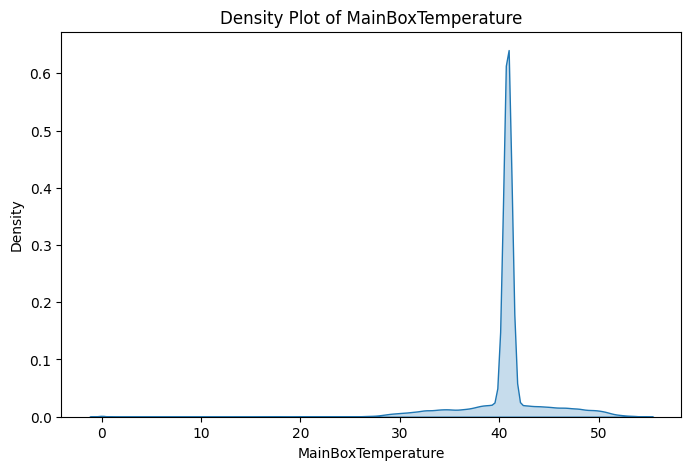

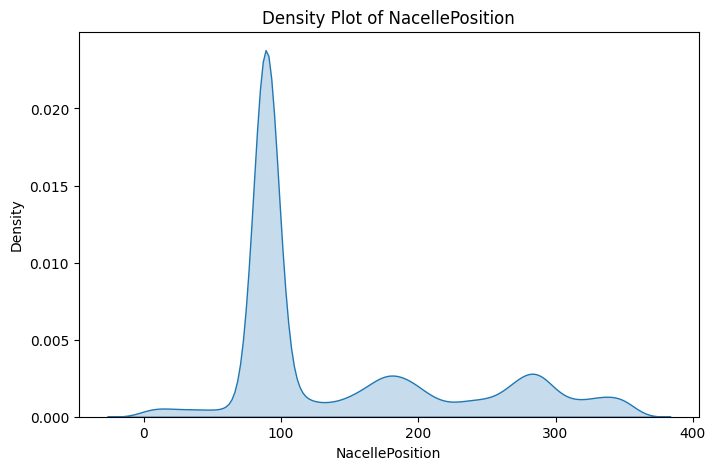

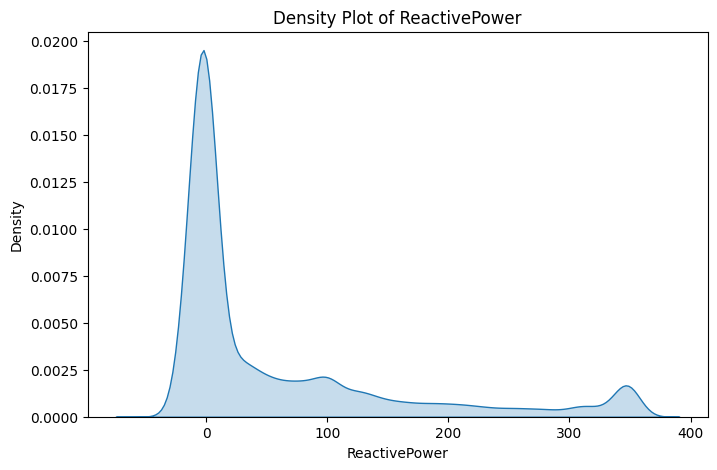

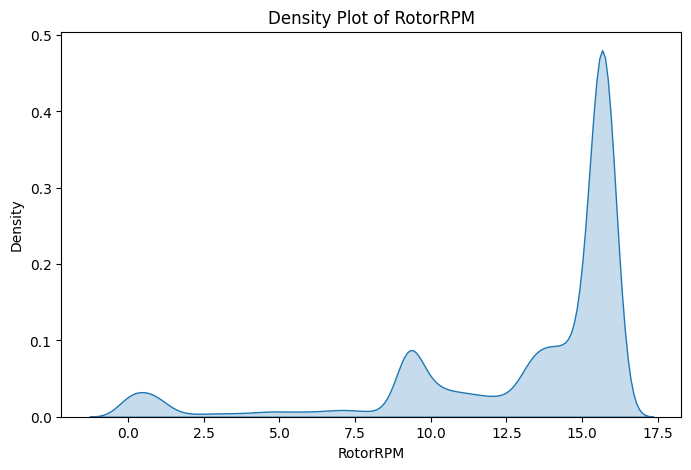

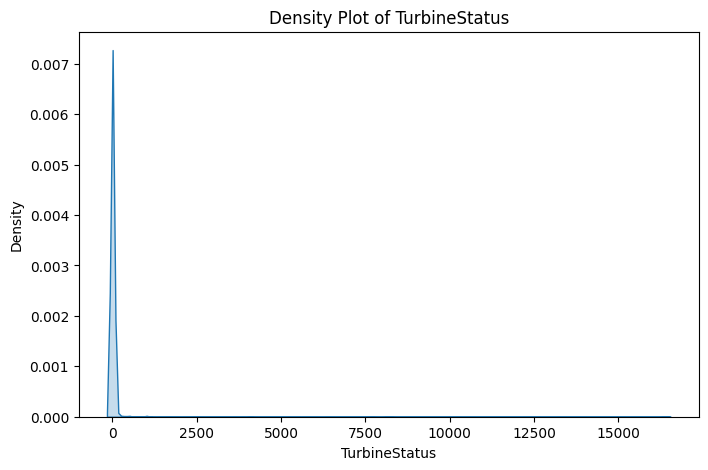

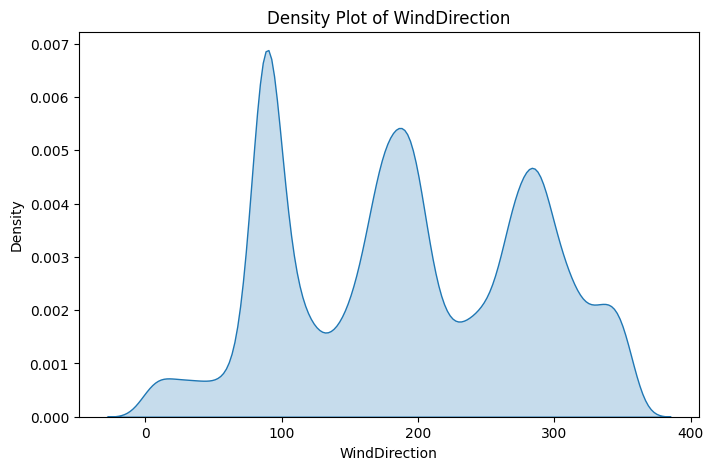

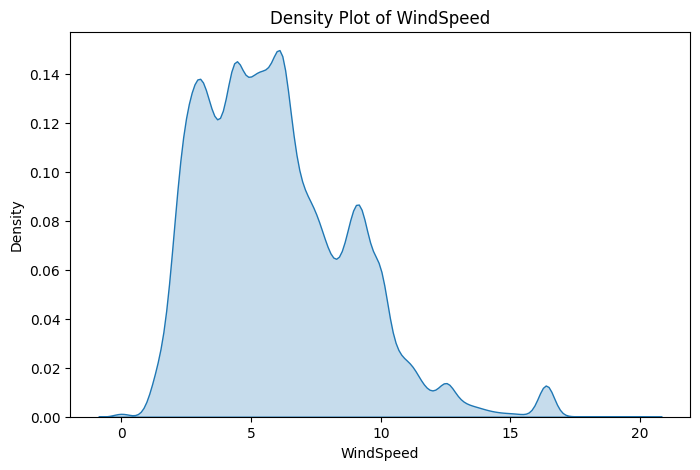

In [ ]:
# Importing Required Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Looping through all numerical columns
for column in data.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(data[column], fill=True)
    plt.title(f'Density Plot of {column}')
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.show()


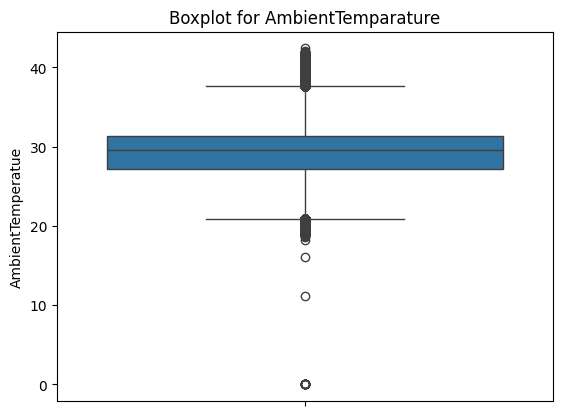

In [ ]:
sns.boxplot(data['AmbientTemperatue'])
plt.title("Boxplot for AmbientTemparature")
plt.show()

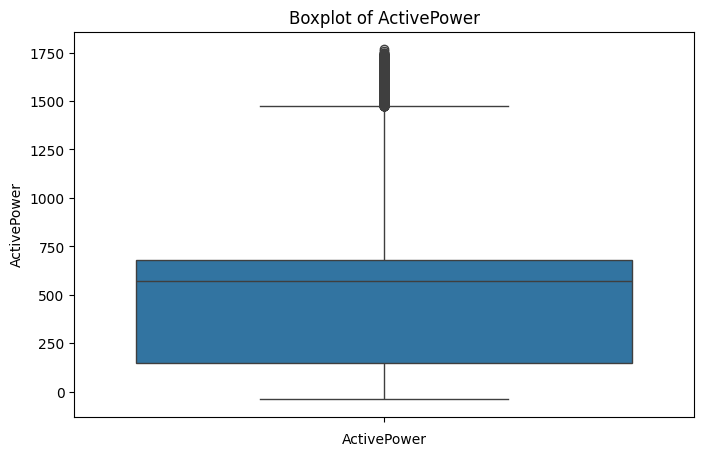

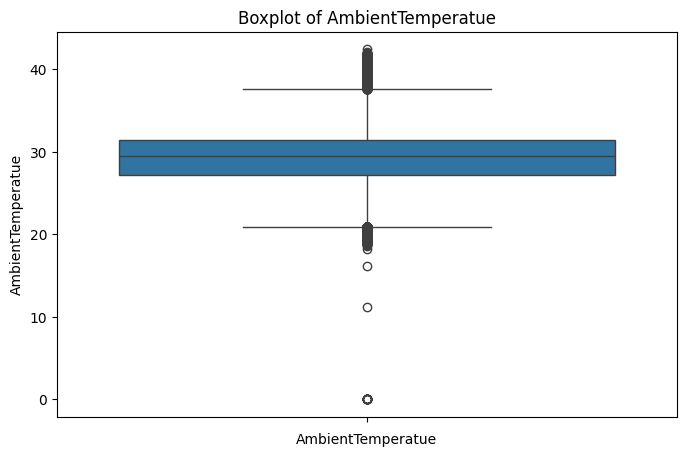

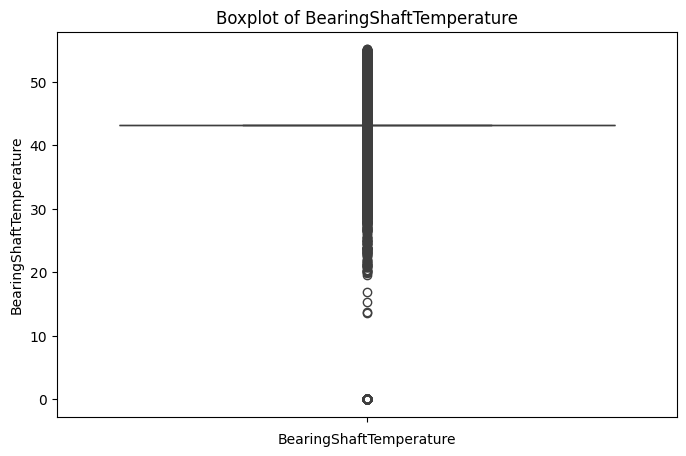

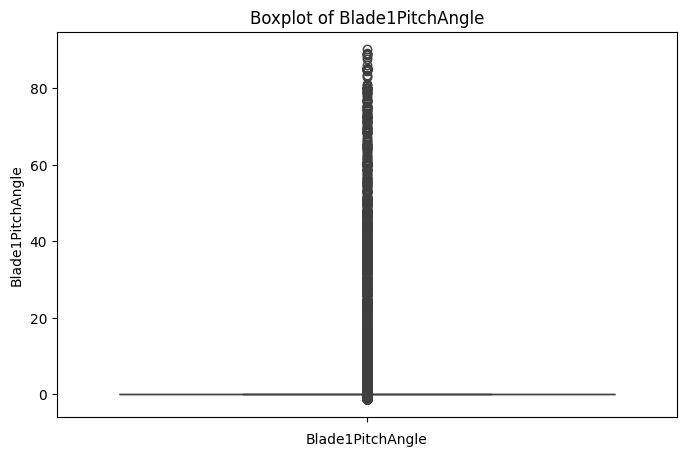

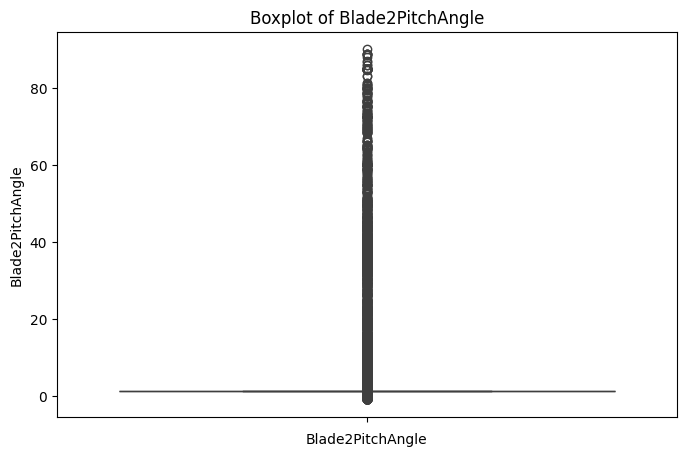

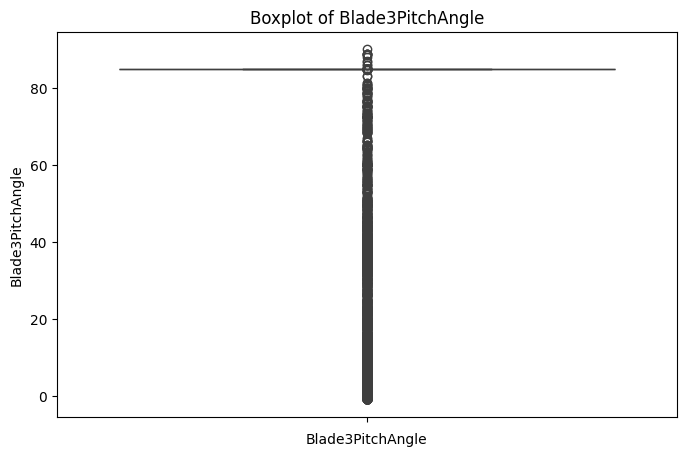

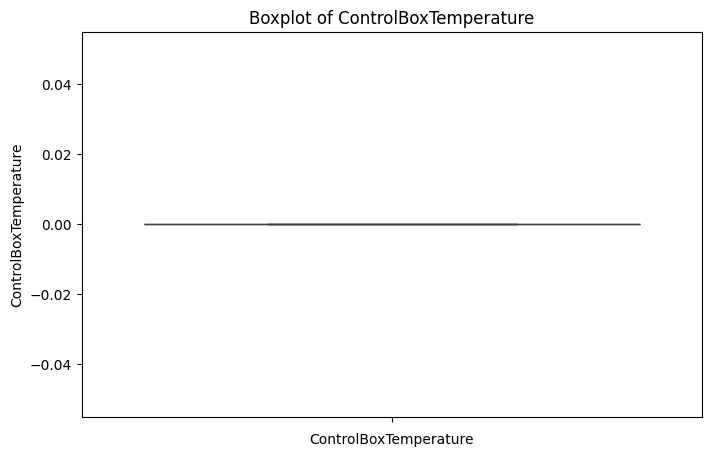

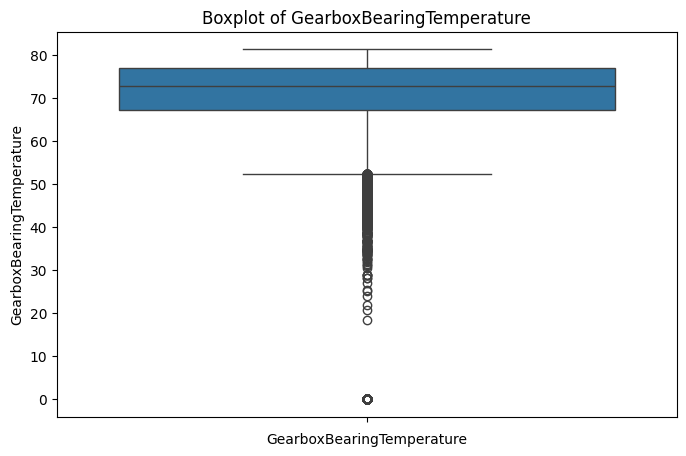

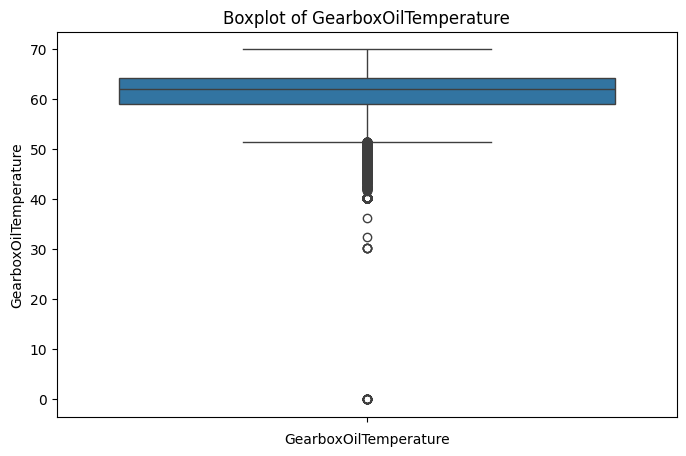

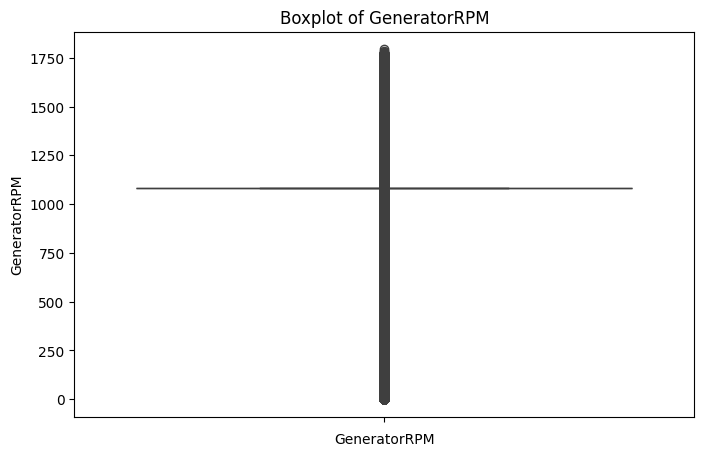

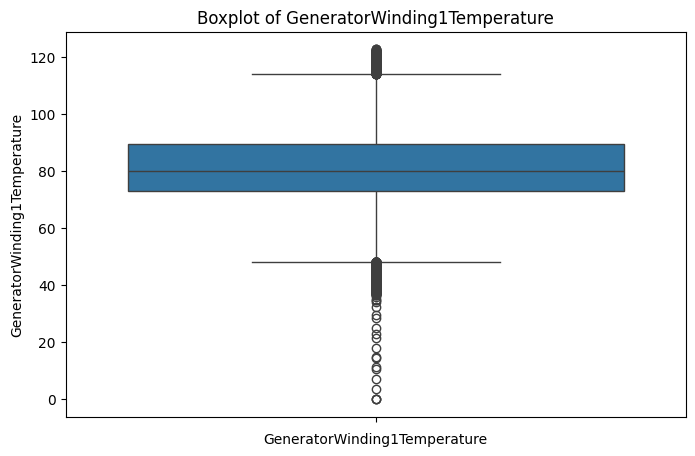

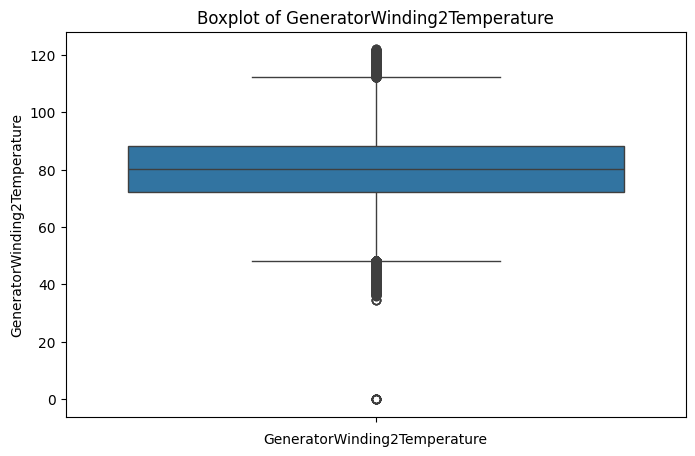

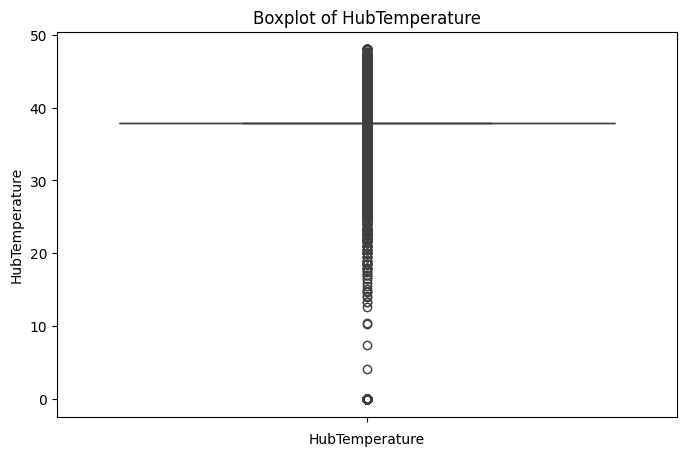

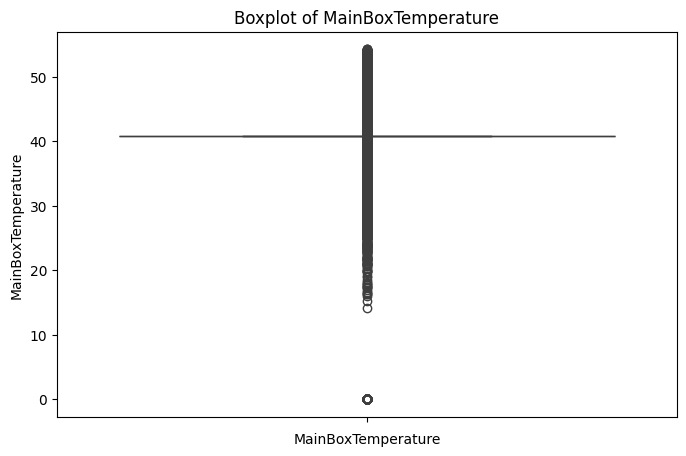

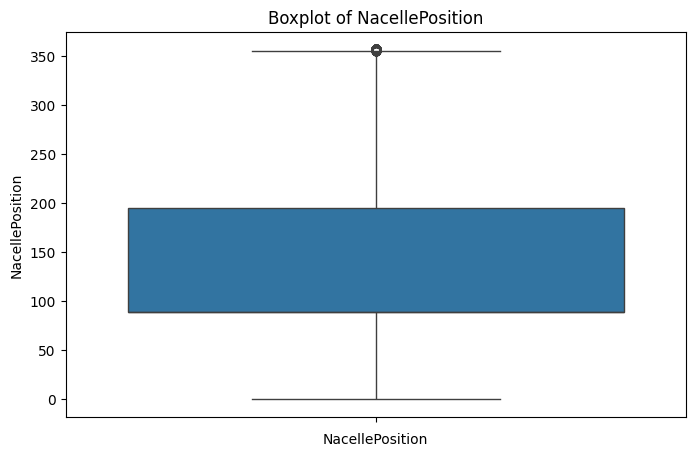

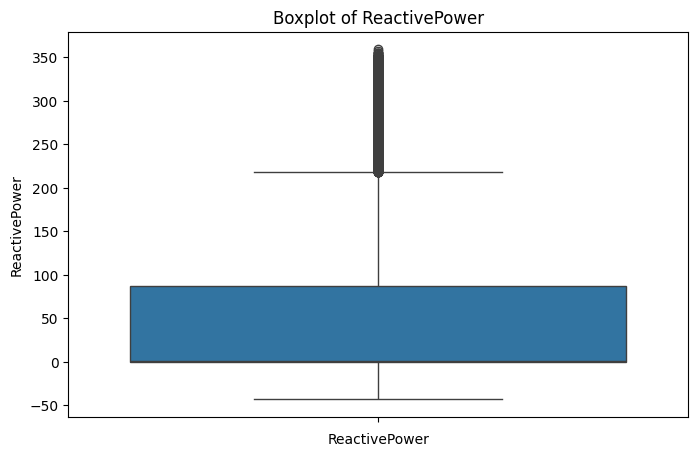

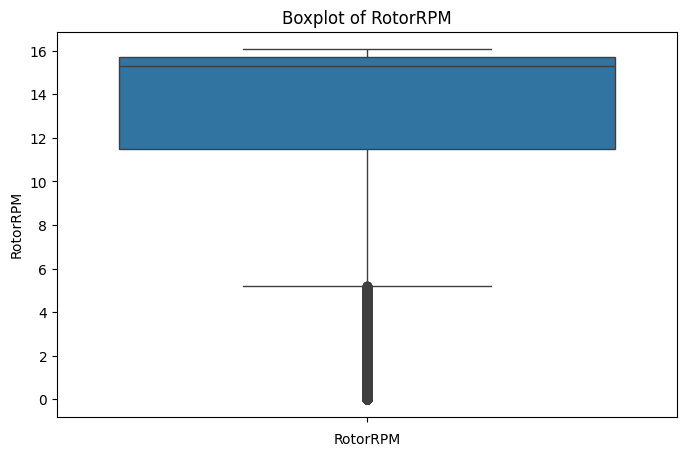

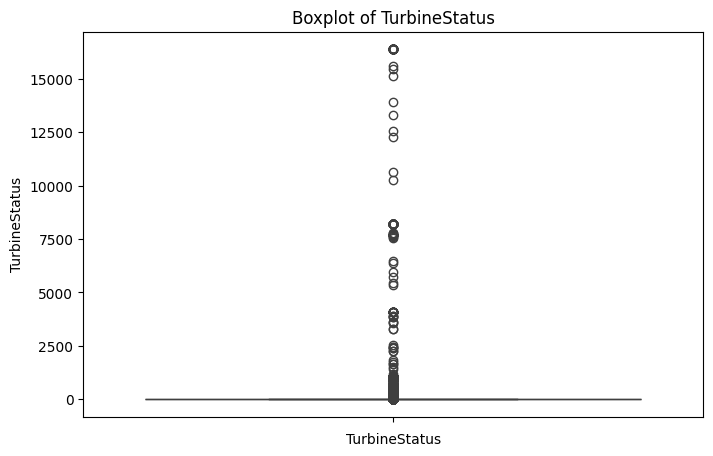

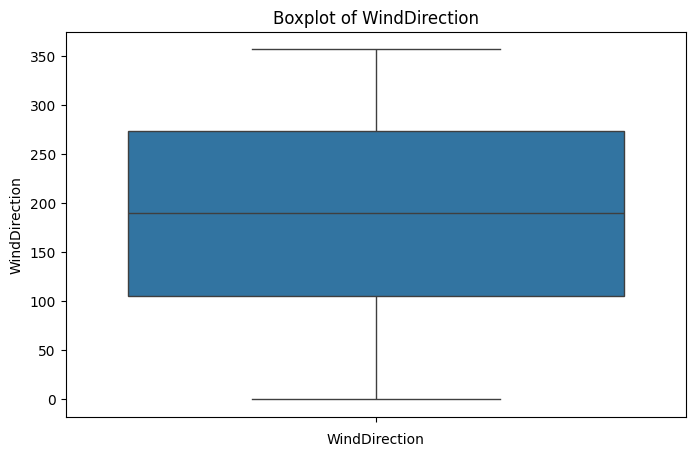

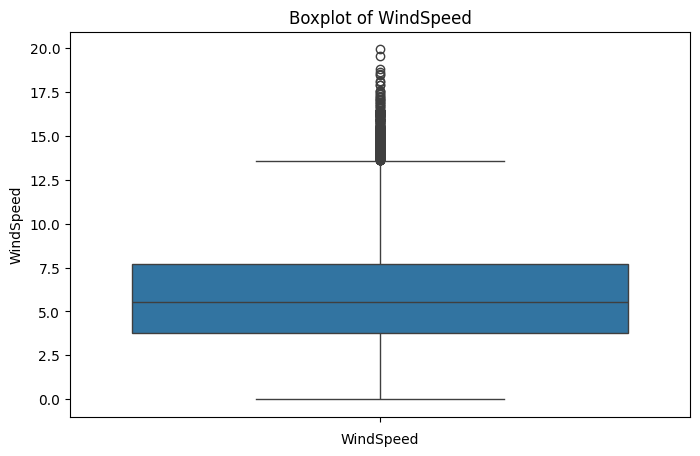

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through all numerical columns
for column in data.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()


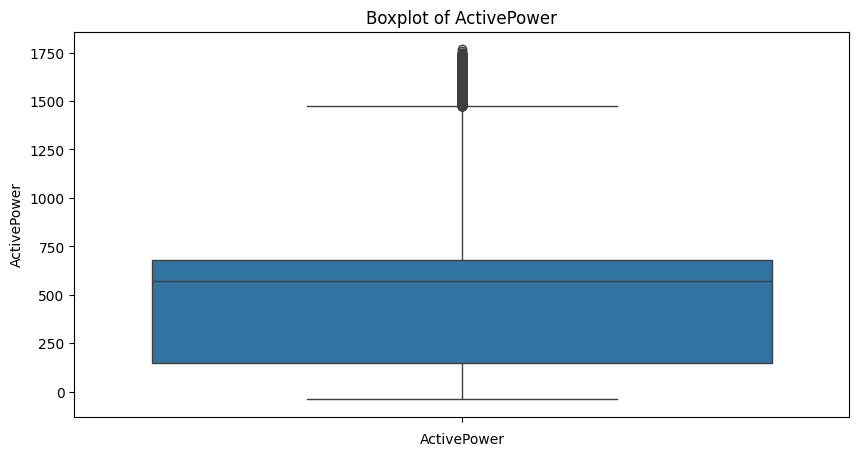

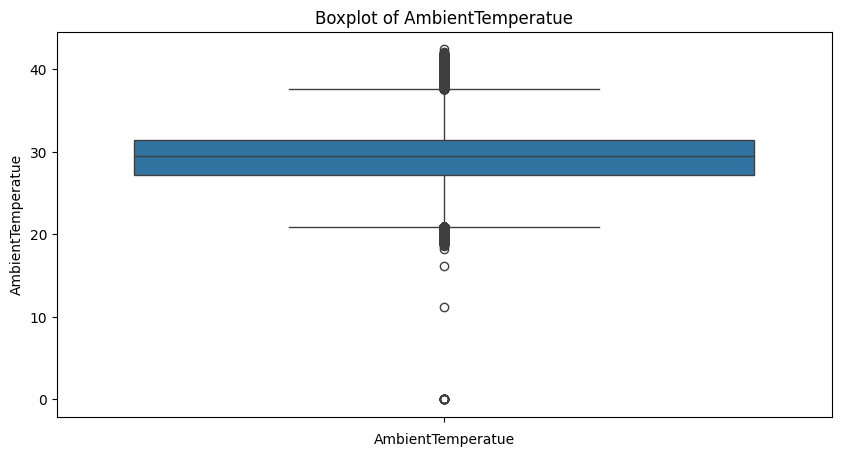

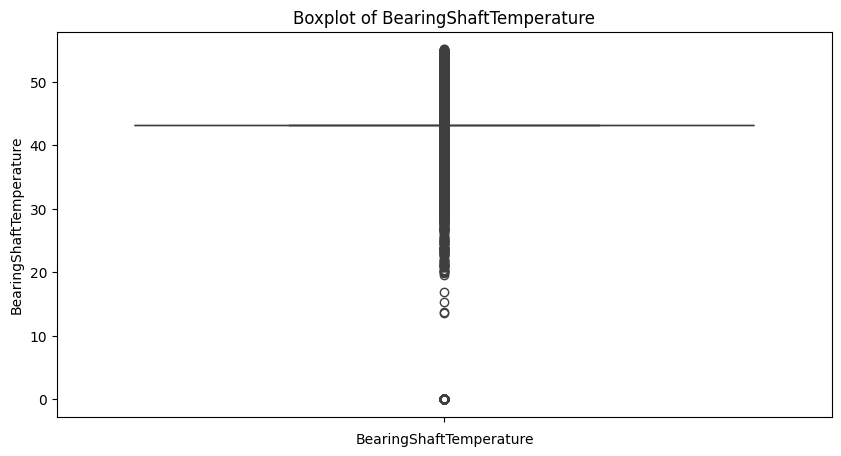

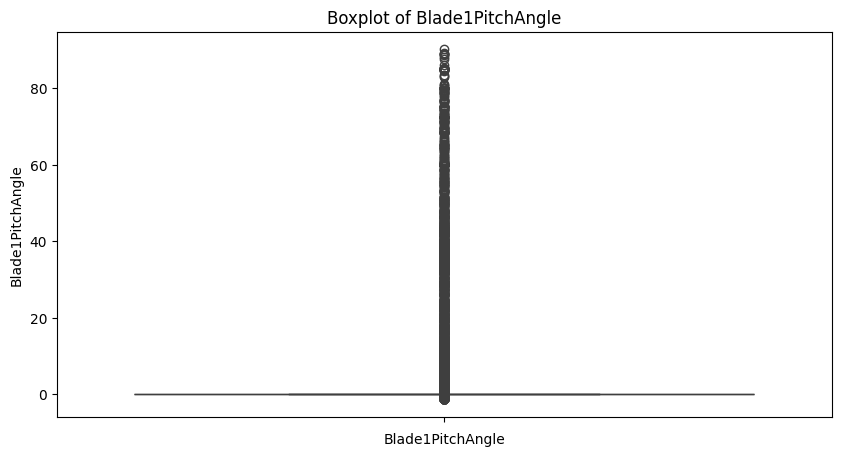

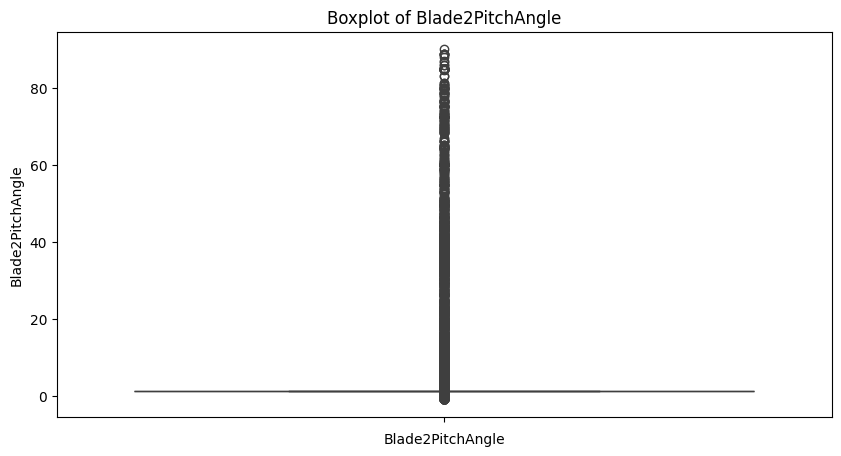

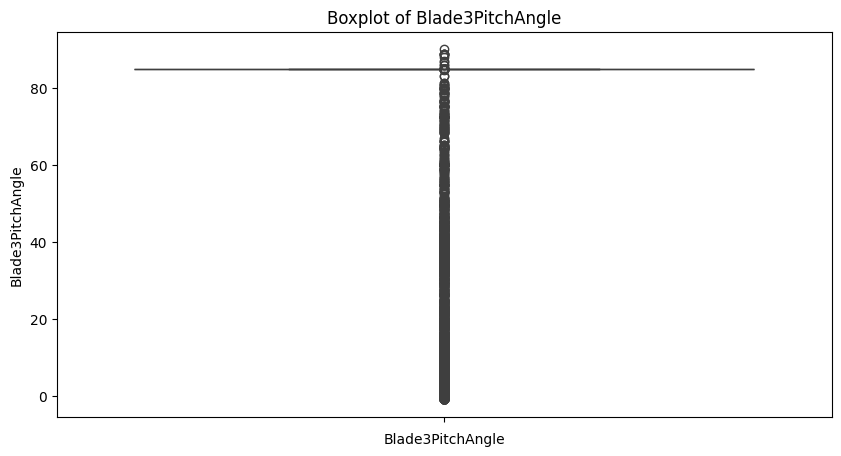

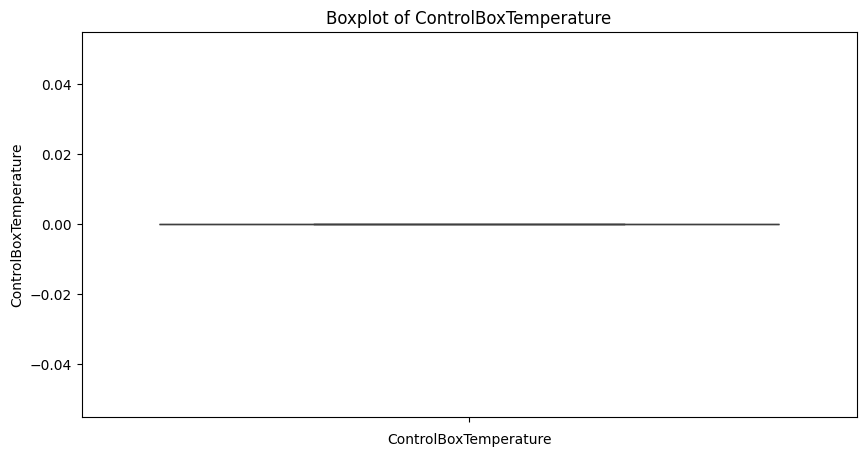

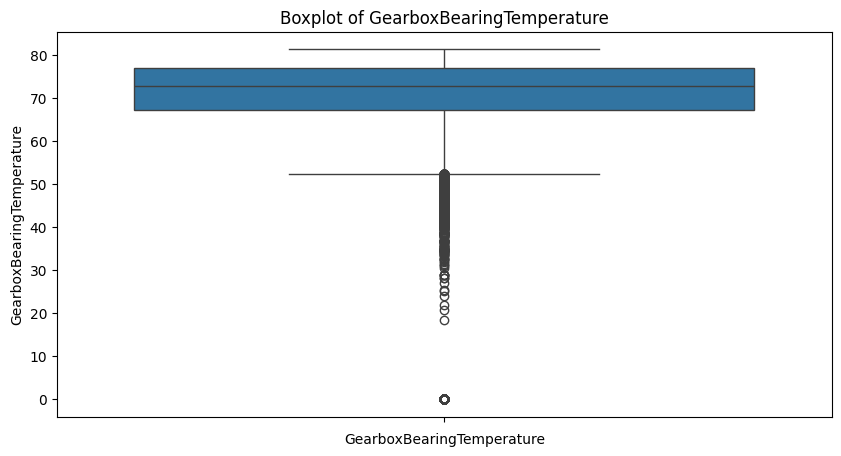

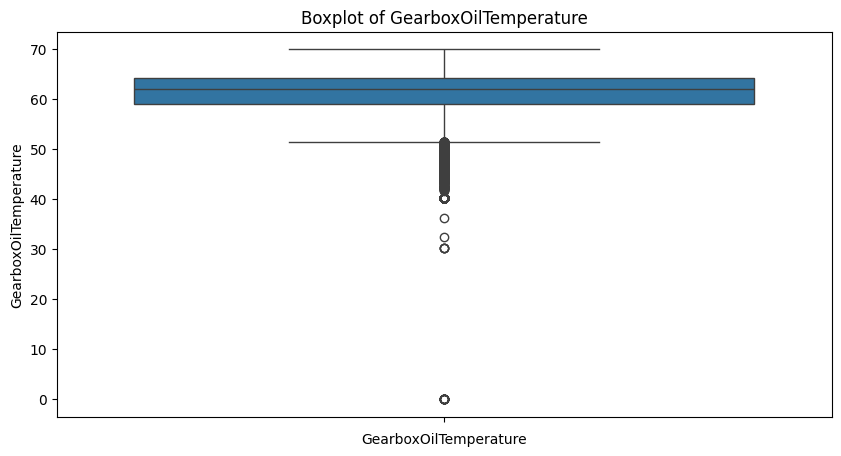

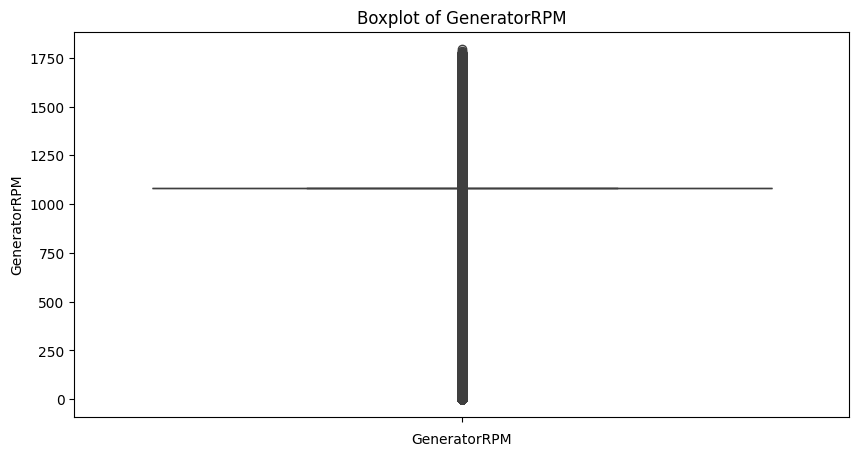

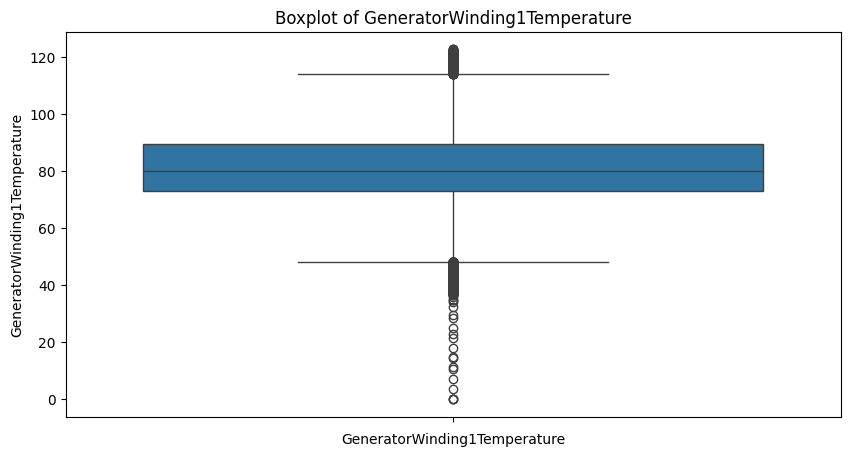

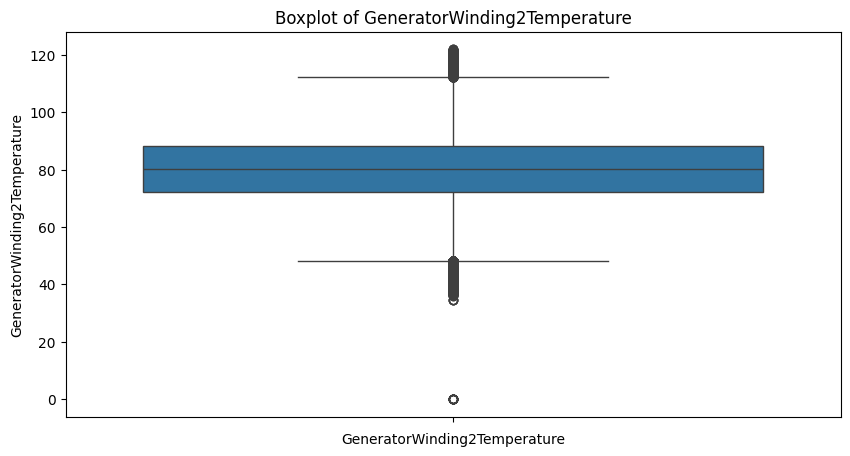

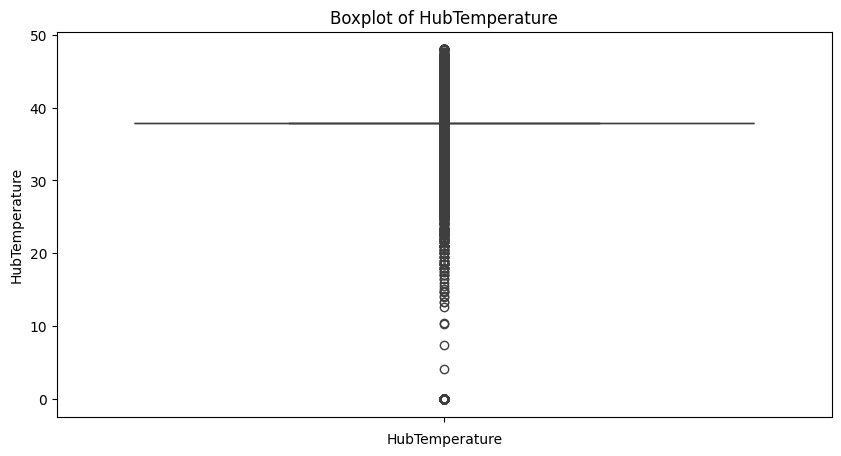

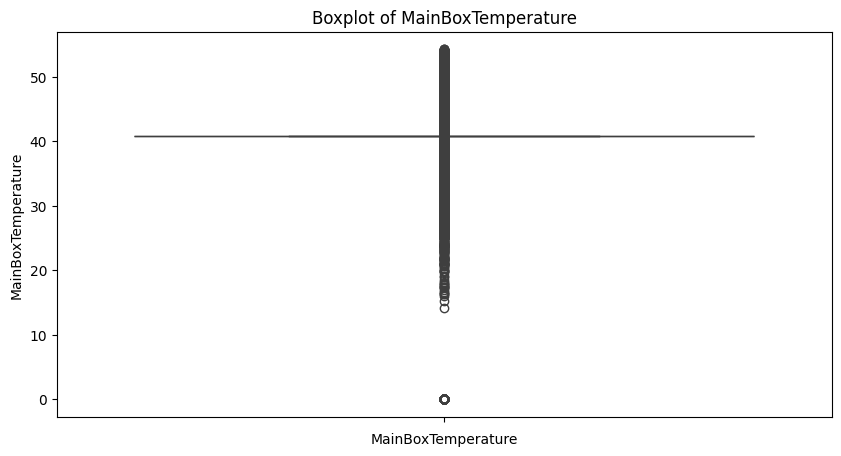

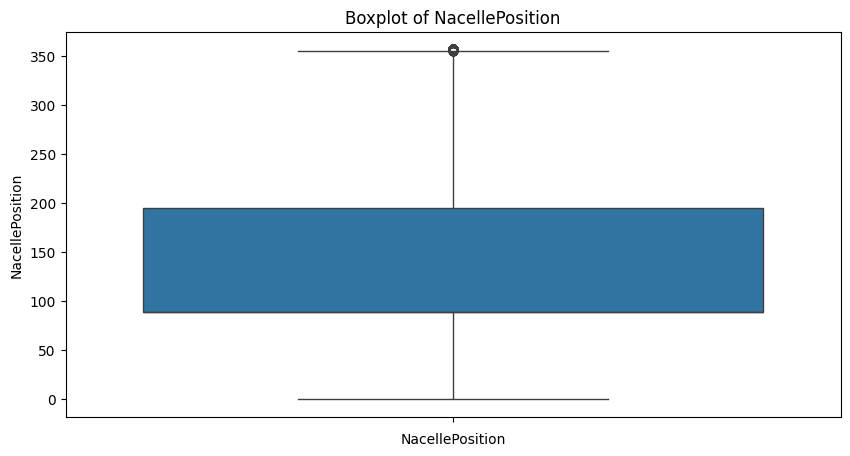

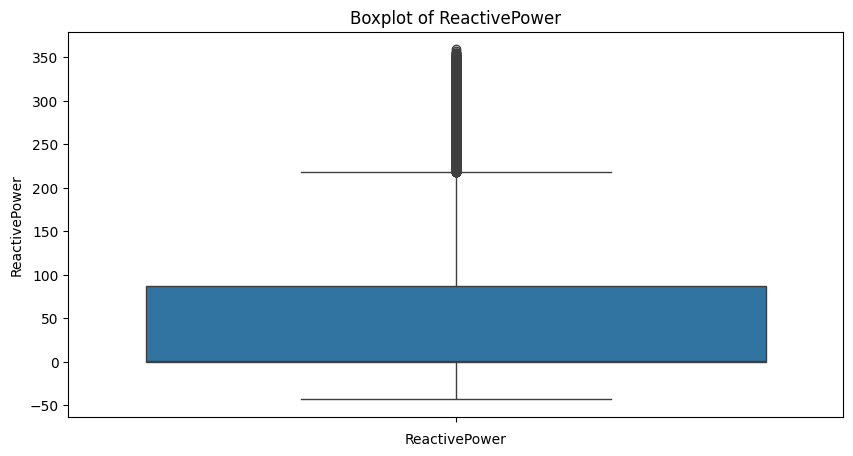

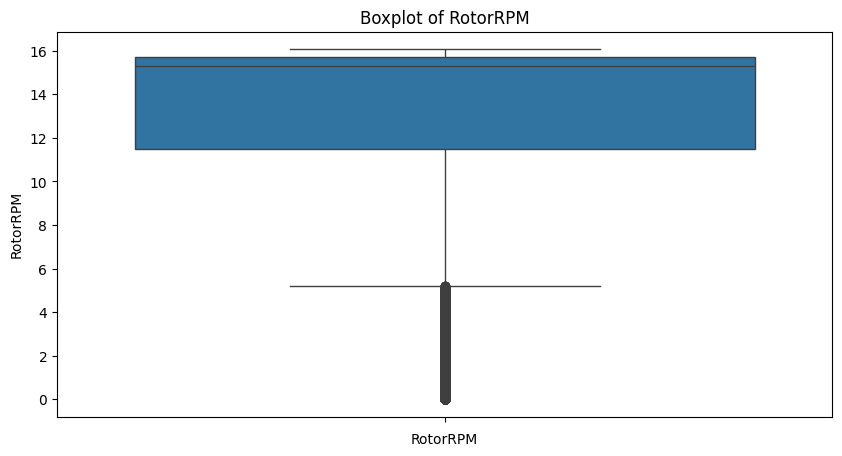

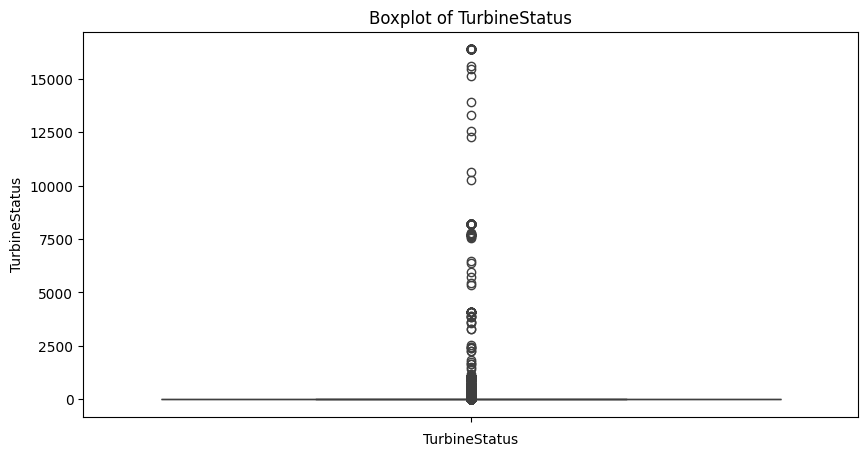

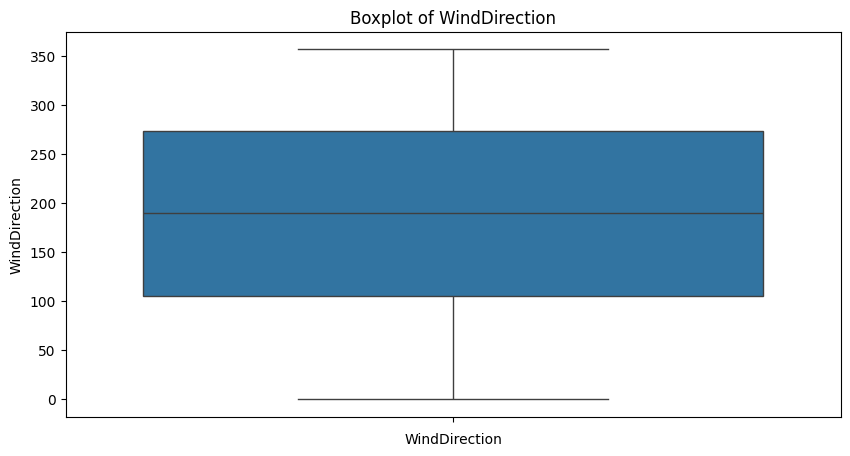

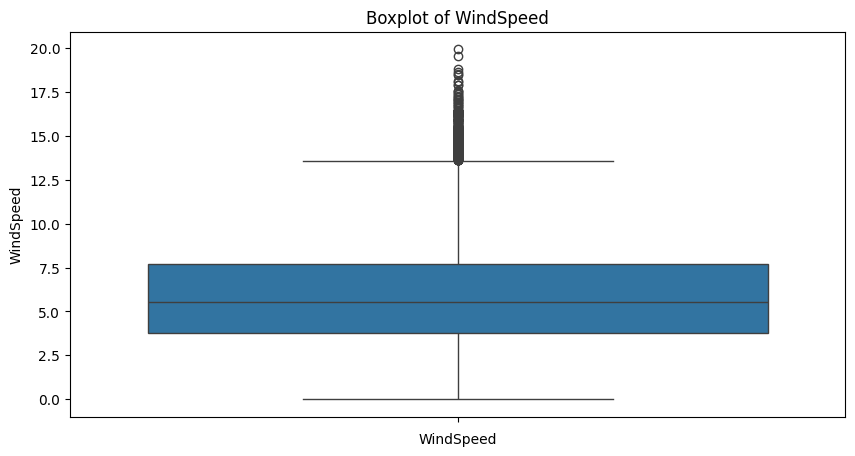

In [ ]:
for col in data.select_dtypes(include=['float64', 'int64']).columns:
  plt.figure(figsize=(10,5))
  sns.boxplot(data[col])
  plt.title(f"Boxplot of {col}")
  plt.xlabel(col)
  plt.show()

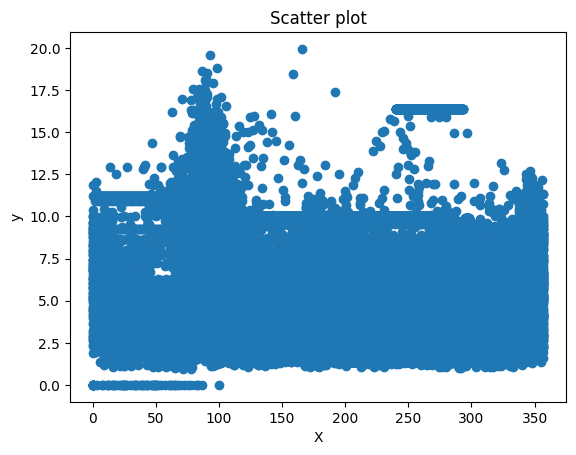

In [ ]:
plt.scatter(data['WindDirection'],data['WindSpeed'])
plt.title("Scatter plot")
plt.xlabel("X")
plt.ylabel('y')
plt.show()

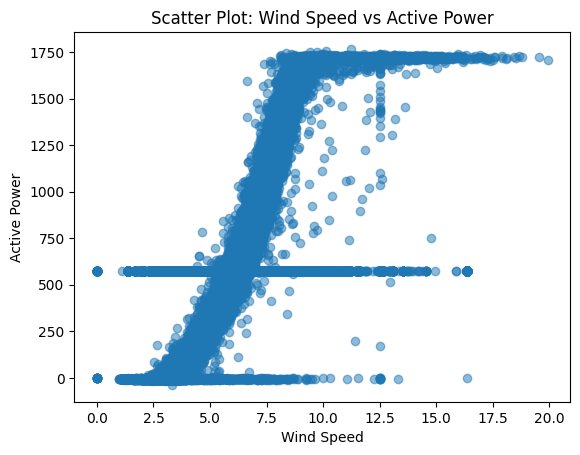

In [ ]:
# Scatter Plot
plt.scatter(data['WindSpeed'], data['ActivePower'], alpha=0.5)
plt.title('Scatter Plot: Wind Speed vs Active Power')
plt.xlabel('Wind Speed')
plt.ylabel('Active Power')
plt.show()

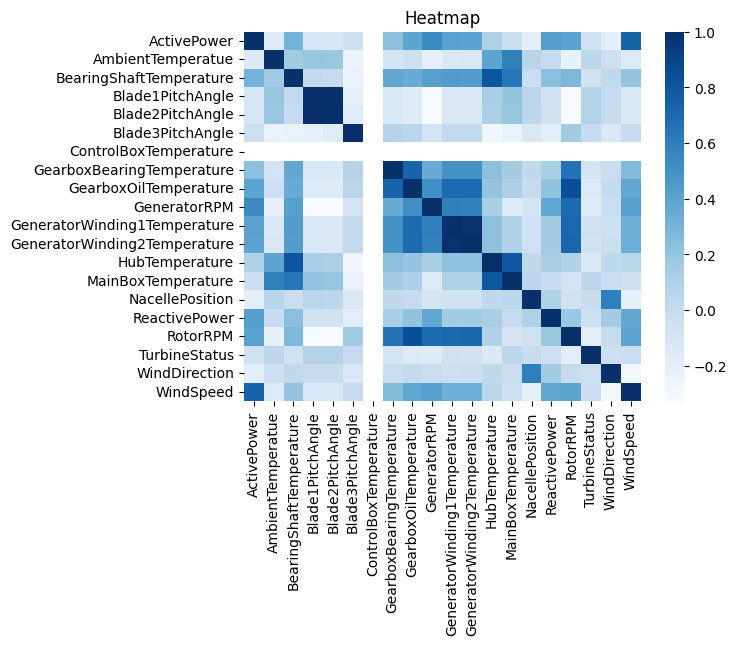

In [ ]:
numeric = data.select_dtypes(include=['float64','int64'])
corr = numeric.corr()
sns.heatmap(corr,cmap='Blues',annot=False)
plt.title('Heatmap')
plt.show()

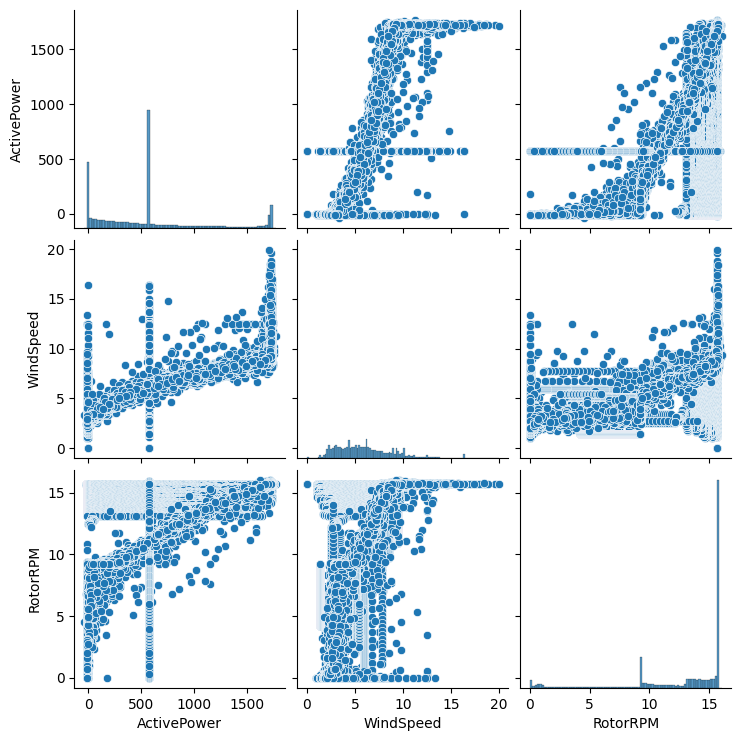

In [ ]:
# Pair Plot
sns.pairplot(data[['ActivePower', 'WindSpeed', 'RotorRPM']])
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [ ]:
# Choose target feature for forecasting (e.g., ActivePower)
time_series = data['ActivePower']

In [ ]:
data['ActivePower'].isna().sum()

np.int64(0)



### **What is ARIMA?**
ARIMA stands for **AutoRegressive Integrated Moving Average**. It is a popular statistical model used for analyzing and forecasting time series data. ARIMA is particularly effective when the data exhibits patterns or trends over time that need to be captured and projected into the future.

---

### **Definition of ARIMA**
ARIMA is a model designed to predict future points in a time series based on its past values (autoregression), the differences between past values (integration), and past forecast errors (moving average). It is represented by the notation **ARIMA(p, d, q)**, where:
- **p**: The number of autoregressive terms (past lags of the dependent variable).
- **d**: The order of differencing required to make the data stationary.
- **q**: The number of moving average terms (lags of the forecast error).

---

### **Purpose of ARIMA**
The primary purpose of ARIMA is:
1. **Forecasting**: Predicting future values of a time series based on its historical data.
2. **Analysis**: Understanding and modeling the underlying patterns in the data, including trends and seasonality.
3. **Stationary Data Transformation**: Adjusting non-stationary time series data into a stationary format for accurate analysis.
4. **Real-World Applications**:
   - Financial markets (stock price prediction).
   - Demand forecasting (supply chain, inventory management).
   - Weather prediction and energy load forecasting.
   - Economic indicators (GDP, inflation rates).

---

### **Phases to Implement ARIMA**
Implementing ARIMA involves several phases:

#### **1. Data Preparation**
- Ensure the time series is univariate (single feature to forecast).
- Handle missing values (e.g., forward-fill or interpolation).
- Convert the data to a stationary format, if required, using techniques like differencing.

#### **2. Stationarity Check**
- Use statistical tests (e.g., Augmented Dickey-Fuller Test) to check if the data is stationary.
- If not stationary, apply differencing (order `d`) until stationarity is achieved.

#### **3. Determine ARIMA Parameters**
- Use ACF (Autocorrelation Function) and PACF (Partial Autocorrelation Function) plots to select:
  - **p** (lags for AR).
  - **q** (lags for MA).
  - Set **d** (based on differencing required for stationarity).

#### **4. Model Building**
- Fit an ARIMA model using the chosen parameters `(p, d, q)`.

#### **5. Model Diagnostics**
- Check residuals (errors) to ensure the model assumptions are valid:
  - Residuals should follow a normal distribution and show no autocorrelation.

#### **6. Forecasting**
- Use the fitted model to forecast future values.
- Plot original series and predictions for comparison.

#### **7. Evaluation**
- Evaluate the model's performance using metrics like RMSE, MAE, or MAPE.
- Compare the actual vs. forecasted values.

---

### **Ways to Implement ARIMA**
ARIMA can be implemented through various methods:
1. **Manual Implementation**:
   - Using Python libraries like `statsmodels` for each phase of ARIMA.
2. **Automated Approaches**:
   - Use `pmdarima` (also known as `auto_arima`) to automatically detect the best `(p, d, q)` parameters and fit the model.
3. **Software Tools**:
   - Tools like R, MATLAB, or Excel also provide built-in functions to perform ARIMA modeling.

---

### **What is the Range for ARIMA Parameters?**
- **p** (Autoregressive terms): 0 to the number of lags where PACF shows significant spikes.
- **d** (Differencing): Generally between 0 and 2 (higher values often lead to overfitting).
- **q** (Moving average terms): 0 to the number of lags where ACF shows significant spikes.

---

### **Parameters to Implement the Model**
The main parameters of ARIMA are:
1. **p (AR)**: The number of lag observations included in the model.
2. **d (I)**: The number of times the series is differenced to achieve stationarity.
3. **q (MA)**: The size of the moving average window (past forecast errors).
4. **Seasonal ARIMA (SARIMA)** Extensions:
   - Add parameters **P, D, Q, m** for seasonality:
     - **P**: Seasonal autoregressive terms.
     - **D**: Seasonal differencing.
     - **Q**: Seasonal moving average.
     - **m**: Seasonal period (e.g., 12 for monthly data).

---

### **Summary**
ARIMA is a powerful tool for forecasting time series data and analyzing patterns. It involves understanding stationarity, selecting appropriate parameters (p, d, q), and performing diagnostics to ensure accurate forecasts. For seasonal data, SARIMA can further enhance predictions by accounting for periodic patterns.


### **Advantages of ARIMA**
1. **Simplicity**: ARIMA is easy to understand and implement, especially for smaller datasets.
2. **Forecast Accuracy**: Provides reliable forecasts for short-term predictions in stationary data.
3. **Flexible Modeling**: Handles both autoregressive (AR) and moving average (MA) processes effectively.
4. **Integration Capability**: Can be extended to seasonal datasets using SARIMA for better performance.
5. **Broad Applications**: Widely used across various domains, including finance, weather forecasting, and inventory management.

---

### **Disadvantages of ARIMA**
1. **Time-Consuming**: **ARIMA takes more time to execute for larger datasets or complex models, especially during hyperparameter tuning and plotting.**
2. **Manual Configuration**: Requires manual selection of parameters (`p`, `d`, `q`), unless using tools like `auto_arima`.
3. **Stationarity Requirement**: Non-stationary data must be transformed before applying ARIMA, adding preprocessing steps.
4. **Limited Long-Term Accuracy**: Forecasting accuracy decreases as the prediction horizon increases.
5. **No Support for Exogenous Variables**: Standard ARIMA models cannot include external influencing factors without modifications (e.g., ARIMAX).

---

### **Limitations of ARIMA**
1. **Univariate Focus**: ARIMA models only one time series at a time and cannot model multivariate relationships without additional methods.
2. **Seasonality Handling**: Standard ARIMA does not account for seasonality; SARIMA must be used for seasonal data.
3. **Large Data Challenges**: Computational complexity increases significantly for very large datasets.
4. **Overfitting Risk**: High parameter values may lead to overfitting, reducing the generalizability of the model.
5. **Poor for Non-linear Patterns**: ARIMA assumes a linear relationship in the data, making it unsuitable for complex, non-linear patterns.

---

### **Assumptions of ARIMA**
1. **Stationarity**: The time series should be stationary (constant mean, variance, and covariance over time). Differencing is applied if this condition isn't met.
2. **Linearity**: ARIMA assumes linear relationships between lagged values and forecasted values.
3. **Normally Distributed Residuals**: The residuals (errors) should follow a normal distribution with no significant autocorrelation.
4. **Sufficient Data**: ARIMA requires a reasonably large dataset (at least 50–100 observations) for reliable results.
5. **Additivity of Components**: Trends, seasonality, and noise in the time series are assumed to add together (not interact non-linearly).

---

### **Statement about Execution Time**
"ARIMA models, particularly when working with large datasets or fine-tuning parameters for best performance, can take considerable time to execute due to the iterative nature of parameter selection and the generation of complex plots like ACF, PACF, and residual diagnostics."



# Check Stationarity
### ARIMA assumes the time series is stationary. Use ADF Test (Augmented Dickey-Fuller) to verify.

If p-value > 0.05, the time series is not stationary. Apply differencing to make it stationary.

In [ ]:
# ADF Test
result = adfuller(time_series)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
if result[1] <= 0.05:
    print("The data is stationary.")
else:
    print("The data is not stationary; differencing may be needed.")


ADF Statistic: -21.152789774891563
p-value: 0.0
The data is stationary.


In [ ]:
# Differencing (if necessary)
time_series_diff = time_series.diff().dropna()


# Model Building
### Fit an ARIMA model. Determine the parameters (p, d, q) through grid search or trial-and-error or use ACF/PACF plots to guide selection.

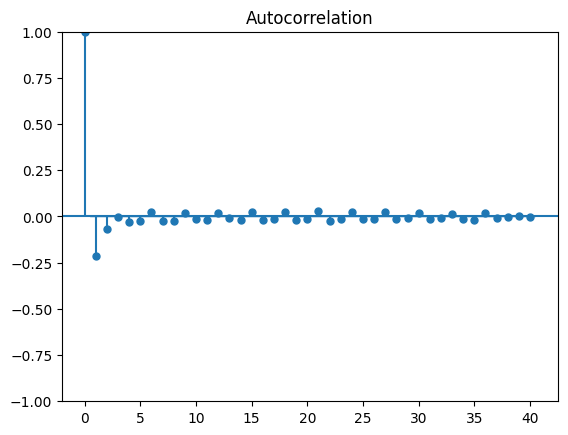

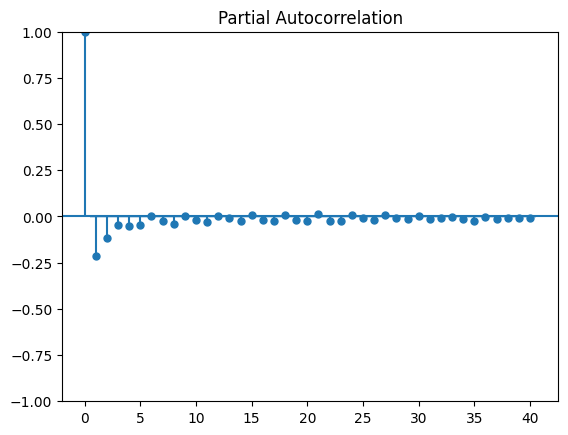

                               SARIMAX Results                                
Dep. Variable:            ActivePower   No. Observations:                76638
Model:                 ARIMA(2, 1, 2)   Log Likelihood             -499522.985
Date:                Tue, 18 Mar 2025   AIC                         999055.970
Time:                        15:21:14   BIC                         999102.205
Sample:                             0   HQIC                        999070.171
                              - 76638                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2120      0.009    135.730      0.000       1.194       1.229
ar.L2         -0.2419      0.008    -29.589      0.000      -0.258      -0.226
ma.L1         -1.4749      0.009   -171.572      0.0

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF
plot_acf(time_series_diff, lags=40)
plot_pacf(time_series_diff, lags=40)
plt.show()
p = 2  # Chosen based on PACF
d = 1  # Chosen based on stationarity test
q = 2  # Chosen based on ACF

# Fit ARIMA model
model = ARIMA(time_series, order=(p, d, q))  # Replace (p, d, q) with chosen values
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())


# Forecasting
## Use the fitted model to make predictions.

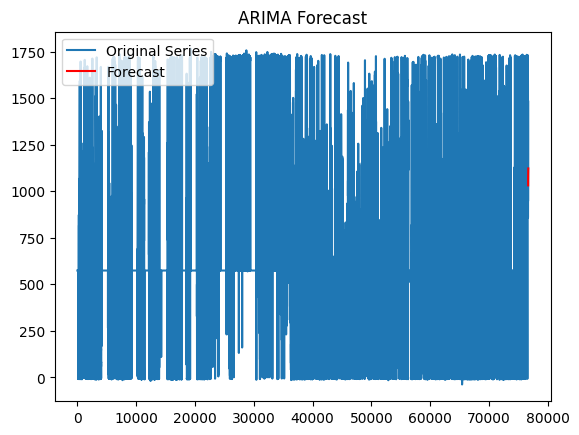

In [ ]:
# Forecast next 'n' steps
forecast_steps = 30  # Number of steps to forecast
forecast = model_fit.forecast(steps=forecast_steps)

# Plot the forecast
plt.plot(time_series, label='Original Series')
plt.plot(forecast.index, forecast, label='Forecast', color='red')
plt.legend()
plt.title('ARIMA Forecast')
plt.show()


# Model Evaluation
## Evaluate the forecasting performance using metrics like RMSE (Root Mean Squared Error).

RMSE: 519.4262414188764


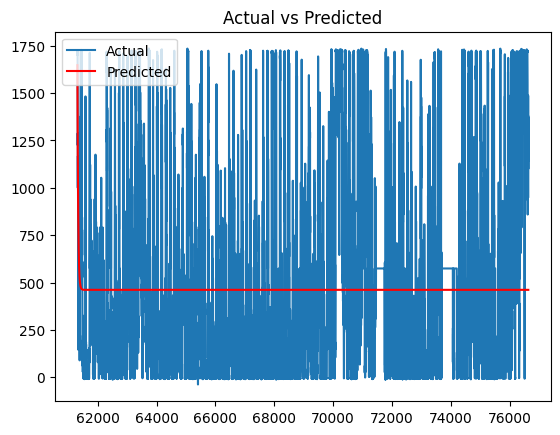

In [ ]:
# Split dataset into training and testing sets
train_size = int(len(time_series) * 0.8)
train, test = time_series[:train_size], time_series[train_size:]

# Fit ARIMA model on training data
model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()

# Predict on test set
predictions = model_fit.forecast(steps=len(test))

# Evaluate using RMSE
rmse = np.sqrt(mean_squared_error(test, predictions))
print("RMSE:", rmse)

# Plot actual vs predicted values
plt.plot(test, label='Actual')
plt.plot(predictions, label='Predicted', color='red')
plt.legend()
plt.title('Actual vs Predicted')
plt.show()


# Advanced Graphs
## Visualize residuals to ensure the model's assumptions are valid.

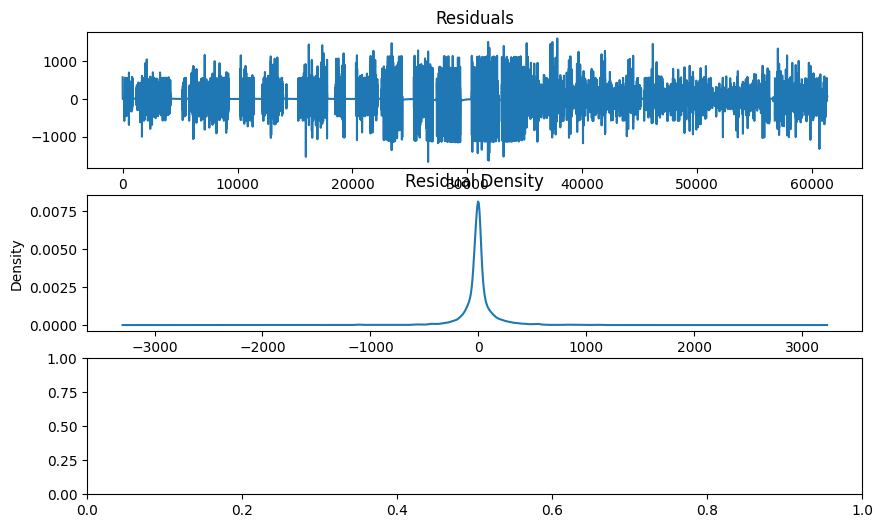

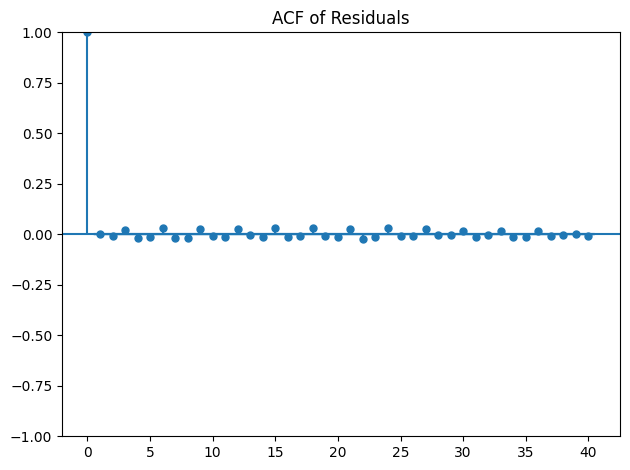

In [ ]:
# Residual diagnostics
residuals = model_fit.resid
plt.figure(figsize=(10, 6))

# Residual plot
plt.subplot(311)
plt.plot(residuals)
plt.title('Residuals')

# Density plot
plt.subplot(312)
residuals.plot(kind='kde')
plt.title('Residual Density')

# ACF of residuals
plt.subplot(313)
plot_acf(residuals, lags=40)
plt.title('ACF of Residuals')
plt.tight_layout()
plt.show()




### **What is SARIMA?**
SARIMA stands for **Seasonal AutoRegressive Integrated Moving Average**. It is an extension of the ARIMA model that accounts for **seasonality** in time series data. Time series models like ARIMA are powerful for forecasting, and SARIMA is particularly useful when the data exhibit periodic patterns or recurring behaviors over time.

---

### **Purpose of SARIMA**
The purpose of SARIMA is to model and predict time series data that include both:
1. **Non-seasonal patterns**, such as trends or random fluctuations.
2. **Seasonal patterns**, which repeat at regular intervals.

By addressing seasonality explicitly, SARIMA can improve forecast accuracy for data such as monthly sales, temperatures, or stock prices.

---

### **Definition of SARIMA**
SARIMA is formally expressed as:  
**SARIMA(p, d, q)(P, D, Q, s)**  

Here are the parameters:
- **p**: Order of the AutoRegressive (AR) component (non-seasonal).
- **d**: Degree of differencing to make the time series stationary (non-seasonal).
- **q**: Order of the Moving Average (MA) component (non-seasonal).
- **P**: Seasonal AR order.
- **D**: Seasonal differencing order.
- **Q**: Seasonal MA order.
- **s**: Length of the seasonal cycle (e.g., 12 for monthly data with yearly seasonality).

---

### **Phases to Implement SARIMA**
Implementing SARIMA involves the following steps:
1. **Identify Stationarity**:
   - Examine the time series for trends and seasonality.
   - Use differencing to remove non-stationary components.
2. **Model Identification**:
   - Use autocorrelation (ACF) and partial autocorrelation (PACF) plots to estimate the parameters (p, d, q) and (P, D, Q, s).
3. **Parameter Tuning**:
   - Test different combinations of parameters to find the best fit using evaluation metrics like AIC, BIC, or RMSE.
4. **Model Fitting**:
   - Fit the SARIMA model to the training data.
5. **Diagnostic Checks**:
   - Analyze residuals to ensure the model captures all patterns.
6. **Forecasting**:
   - Generate future predictions.

---

### **Ways to Implement SARIMA**
SARIMA can be implemented using statistical software or programming tools:
- **Python**: Libraries such as `statsmodels` make it easy to implement SARIMA models.
- **R**: Functions like `sarima()` in R are available for seasonal modeling.
- **Excel**: Limited but can perform basic ARIMA modeling with add-ins.
  
For Python implementation:
```python
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(data, order=(p, d, q), seasonal_order=(P, D, Q, s))
fit_model = model.fit()
predictions = fit_model.forecast(steps=12)
print(predictions)
```

---

### **Parameter Ranges**
The range of SARIMA parameters depends on the time series data but generally:
- **p, q, P, Q**: Usually between 0–3 (higher values may lead to overfitting).
- **d, D**: Differencing values are typically 0–2.
- **s**: Seasonal length, e.g., 12 for monthly data (12 months in a year).

---

### **Advantages of SARIMA**
- Models both trend and seasonality.
- Handles non-stationarity through differencing.
- Widely applicable to real-world time series with seasonal behaviors.

---

### **Disadvantages of SARIMA**
- Computationally intensive for large datasets.
- Sensitive to incorrect parameter selection.
- Assumes linear relationships in time series, which may not capture complex dynamics.

---

### **Limitations of SARIMA**
- Requires stationary data (may need transformation).
- Does not handle external variables (like ARIMAX or SARIMAX).
- Inflexible for sudden shocks or anomalies in data.

---

### **Assumptions of SARIMA**
1. Time series must be stationary (mean and variance are constant over time).
2. Relationship between observations is linear.
3. No significant outliers or missing data.
4. Assumes seasonality is consistent over time.

---


<ipython-input-63-e6d69bc964be>:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  time_series = time_series.fillna(method='ffill')


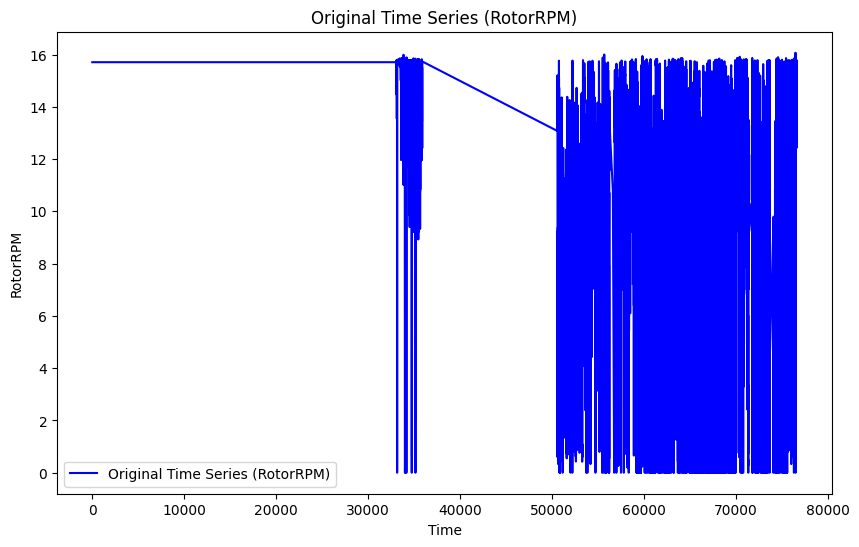

In [ ]:
# Choose the target feature (RotorRPM) for time series analysis
time_series = data['RotorRPM']

# Handle missing values (using forward-fill method)
time_series = time_series.fillna(method='ffill')

# Visualize the original time series
plt.figure(figsize=(10, 6))
plt.plot(time_series, label='Original Time Series (RotorRPM)', color='blue')
plt.title('Original Time Series (RotorRPM)')
plt.xlabel('Time')
plt.ylabel('RotorRPM')
plt.legend()
plt.show()

# Stationarity Check
## We check if the time series is stationary using the Augmented Dickey-Fuller (ADF) test.

The adfuller function tests the null hypothesis that the series is non-stationary.

If the p-value > 0.05, the series is not stationary, and we need to apply differencing.

In [ ]:
from statsmodels.tsa.stattools import adfuller
# perform the ADF test
result = adfuller(time_series)
print("ADF Statistics: " ,result[0])
print("p-value: ", result[1])
if result[1] <= 0.05:
  print("The data is Stationary")
else:
  print("The data is not Stationary. Differencing will be applied")

ADF Statistics:  -13.842791948939661
p-value:  7.240597471773402e-26
The data is Stationary


# Apply Differencing (if needed)
## Differencing helps make the series stationary by removing trends or seasonality.

Differencing (.diff()) calculates the difference between consecutive data points.

dropna() removes the first row since differencing generates a NaN value at the start.

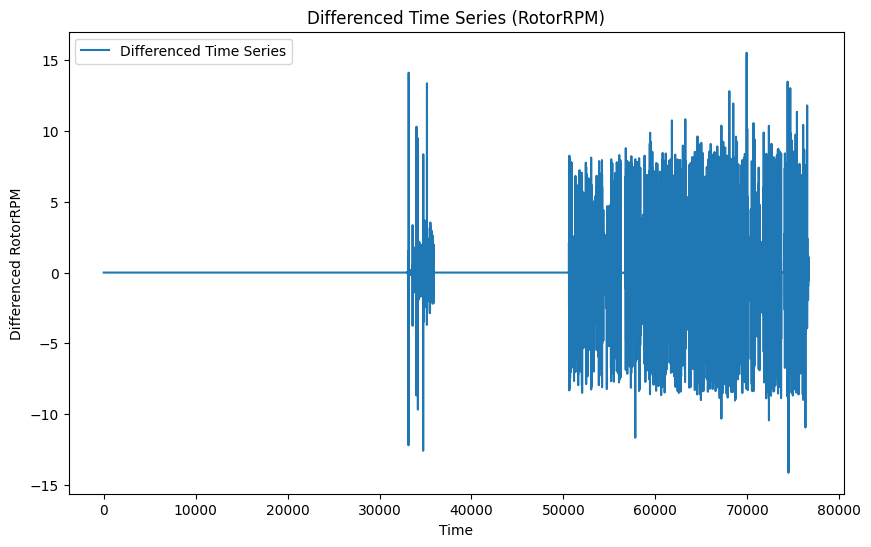

In [ ]:
# Apply differencing to make the series stationary
time_series_diff = time_series.diff().dropna()

# Visualize the differenced time series
plt.figure(figsize=(10, 6))
plt.plot(time_series_diff, label='Differenced Time Series')
plt.title('Differenced Time Series (RotorRPM)')
plt.xlabel('Time')
plt.ylabel('Differenced RotorRPM')
plt.legend()
plt.show()


# Build the SARIMA Model
## We set SARIMA parameters (p, d, q, P, D, Q, m) and fit the model.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define the seasonal period (e.g., 12 for monthly seasonality)
seasonal_period = 12

# Set SARIMA parameters (p, d, q, P, D, Q, m)
p, d, q = 2, 1, 2  # Non-seasonal parameters
P, D, Q, m = 1, 1, 1, seasonal_period  # Seasonal parameters and seasonal period

# Fit the SARIMA model
model = SARIMAX(time_series,
                order=(p, d, q),
                seasonal_order=(P, D, Q, m),
                enforce_stationarity=False,
                enforce_invertibility=False)
model_fit = model.fit(disp=False)  # Suppress optimization logs

# Print the model summary
print(model_fit.summary())


                                      SARIMAX Results                                       
Dep. Variable:                             RotorRPM   No. Observations:                76638
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood             -115045.988
Date:                              Tue, 18 Mar 2025   AIC                         230105.975
Time:                                      15:24:52   BIC                         230170.701
Sample:                                           0   HQIC                        230125.856
                                            - 76638                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2480      0.072     -3.445      0.001      -0.389      -0.107
ar.L2          0.41

# Forecasting
## Forecast future values based on the fitted model.

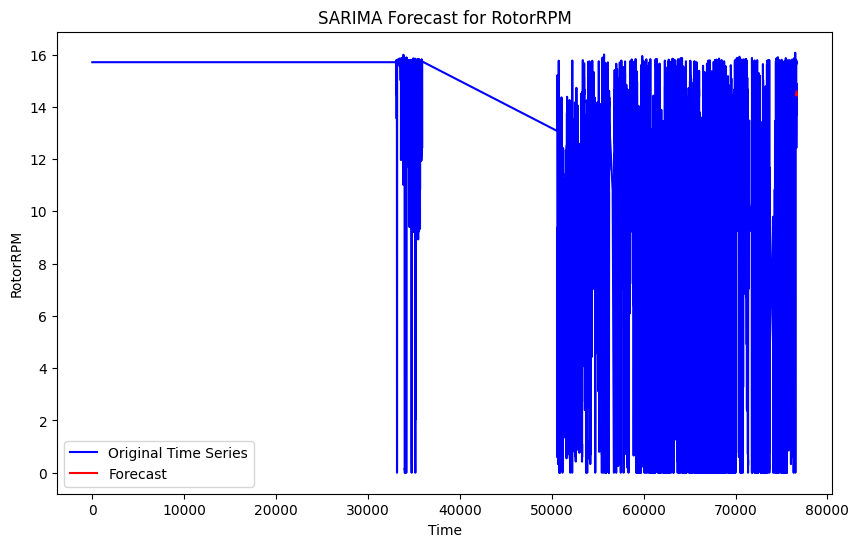

In [ ]:
# Forecast the next 30 time periods
forecast_steps = 30
forecast = model_fit.forecast(steps=forecast_steps)

# Plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(time_series, label='Original Time Series', color='blue')
plt.plot(forecast.index, forecast, label='Forecast', color='red')
plt.title('SARIMA Forecast for RotorRPM')
plt.xlabel('Time')
plt.ylabel('RotorRPM')
plt.legend()
plt.show()


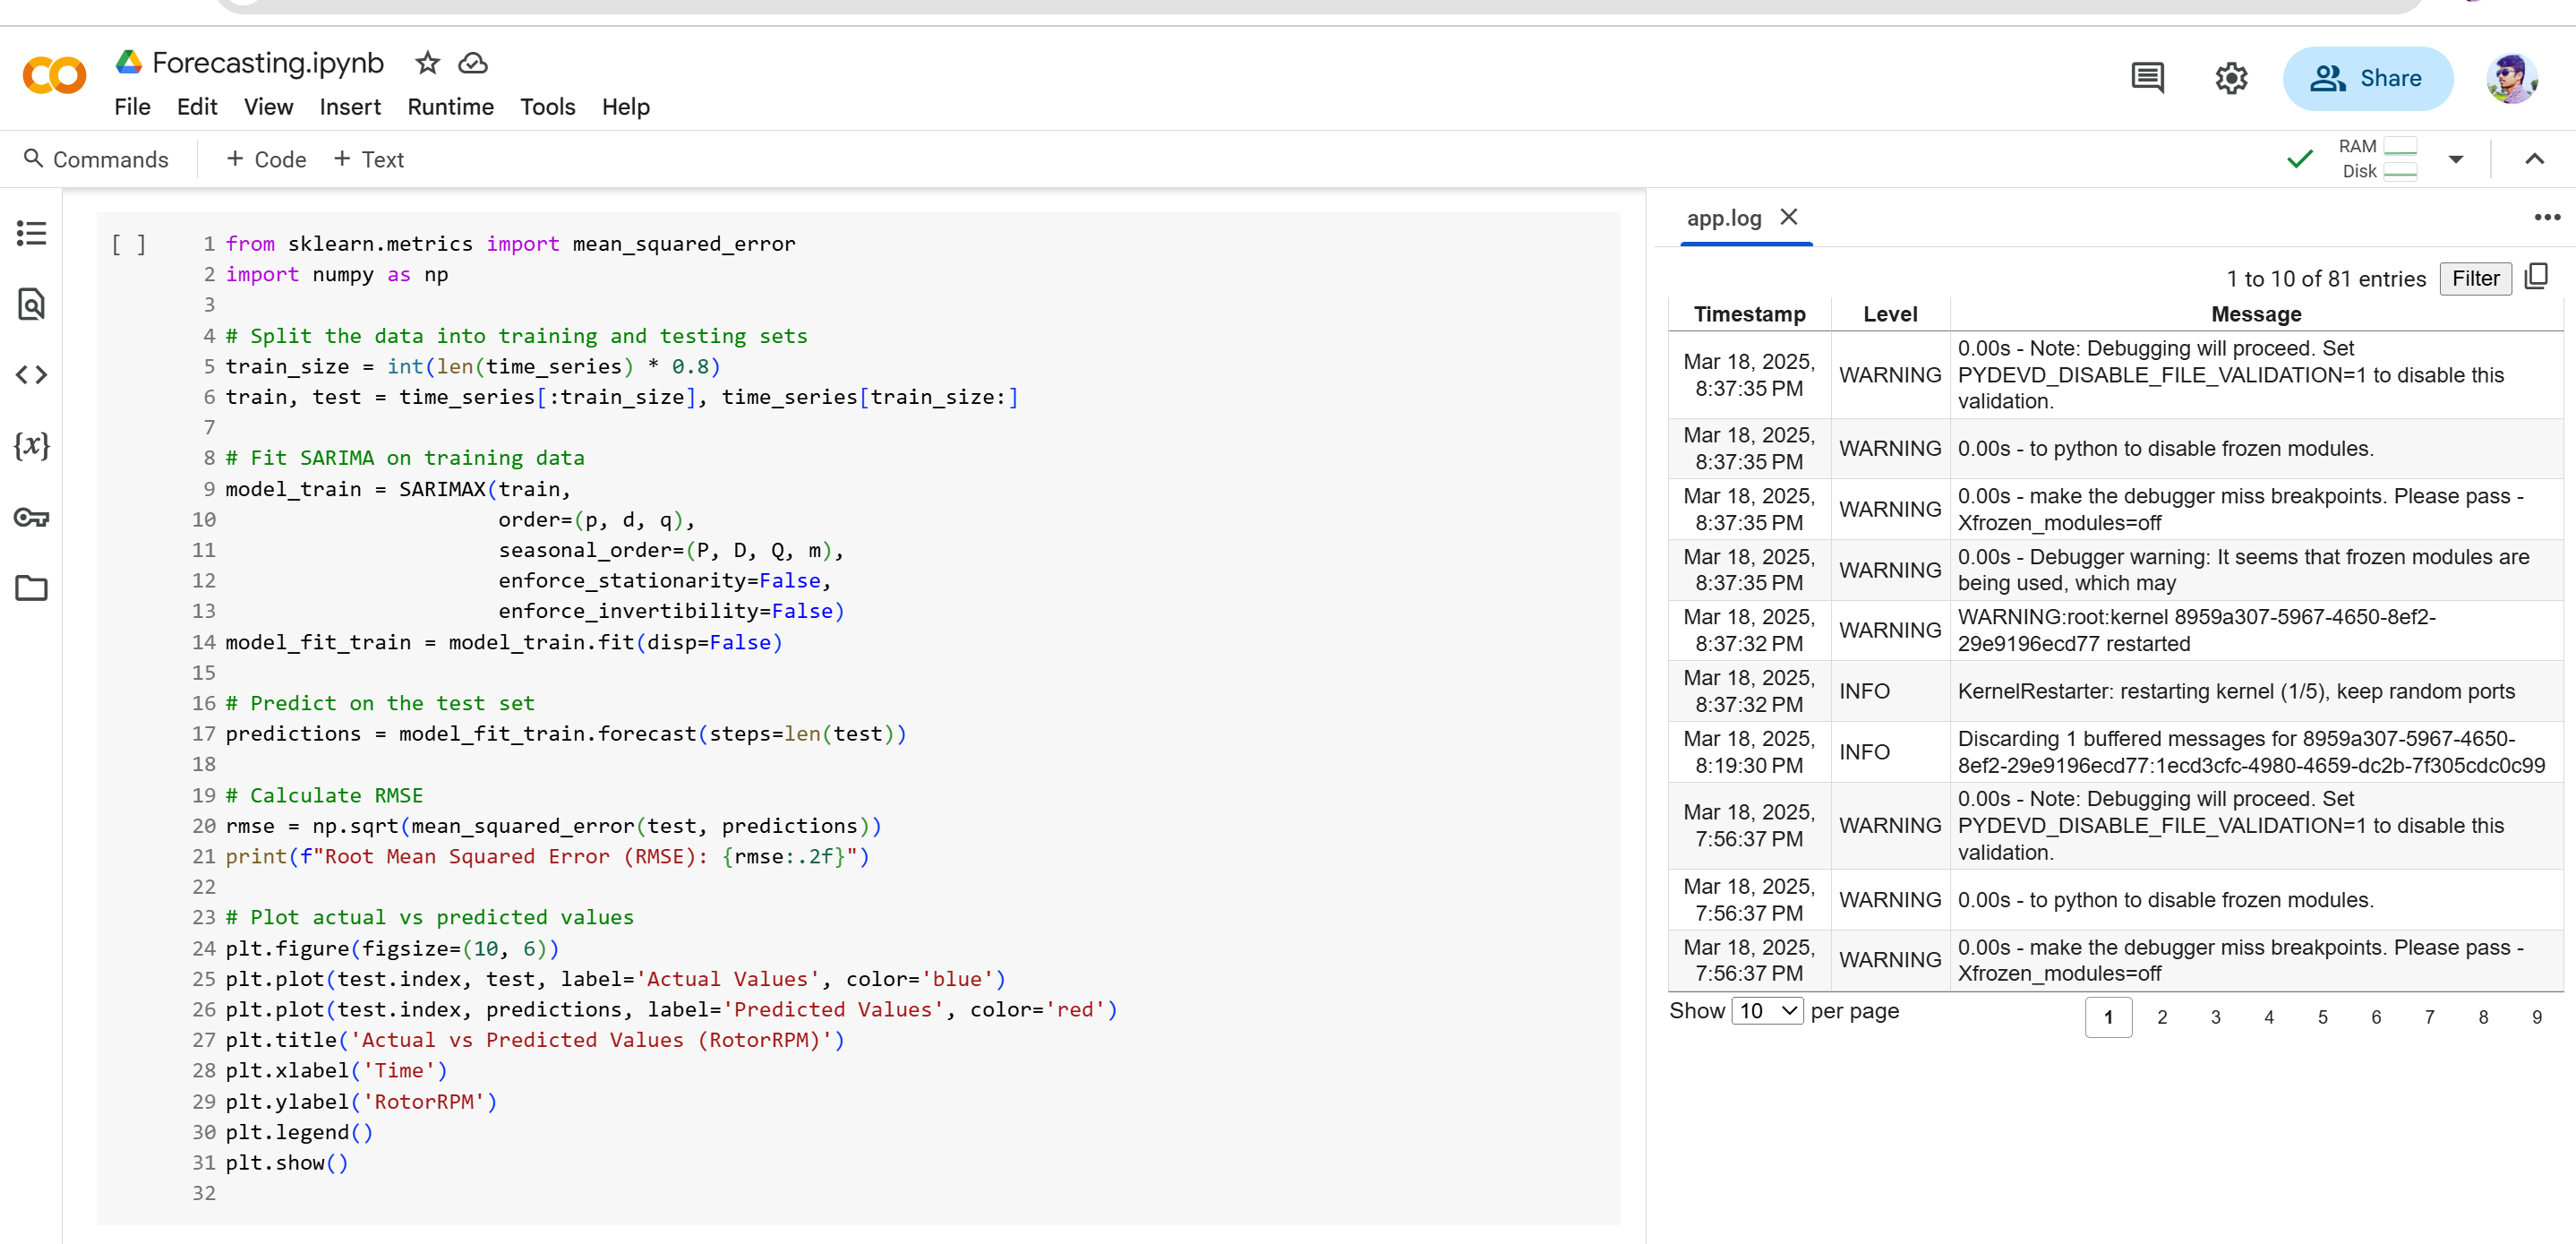